In [4]:
path=r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/output/frb1st_F.png"

### here we use the 1st FRBs img (processed acc to the chime pipeline) to de noise it further
additionally we can also look the img just afer the RFI reduction (NO BOXAR COnvolution) to deal with it. 

findfont: Failed to find font weight medium, now using 400.


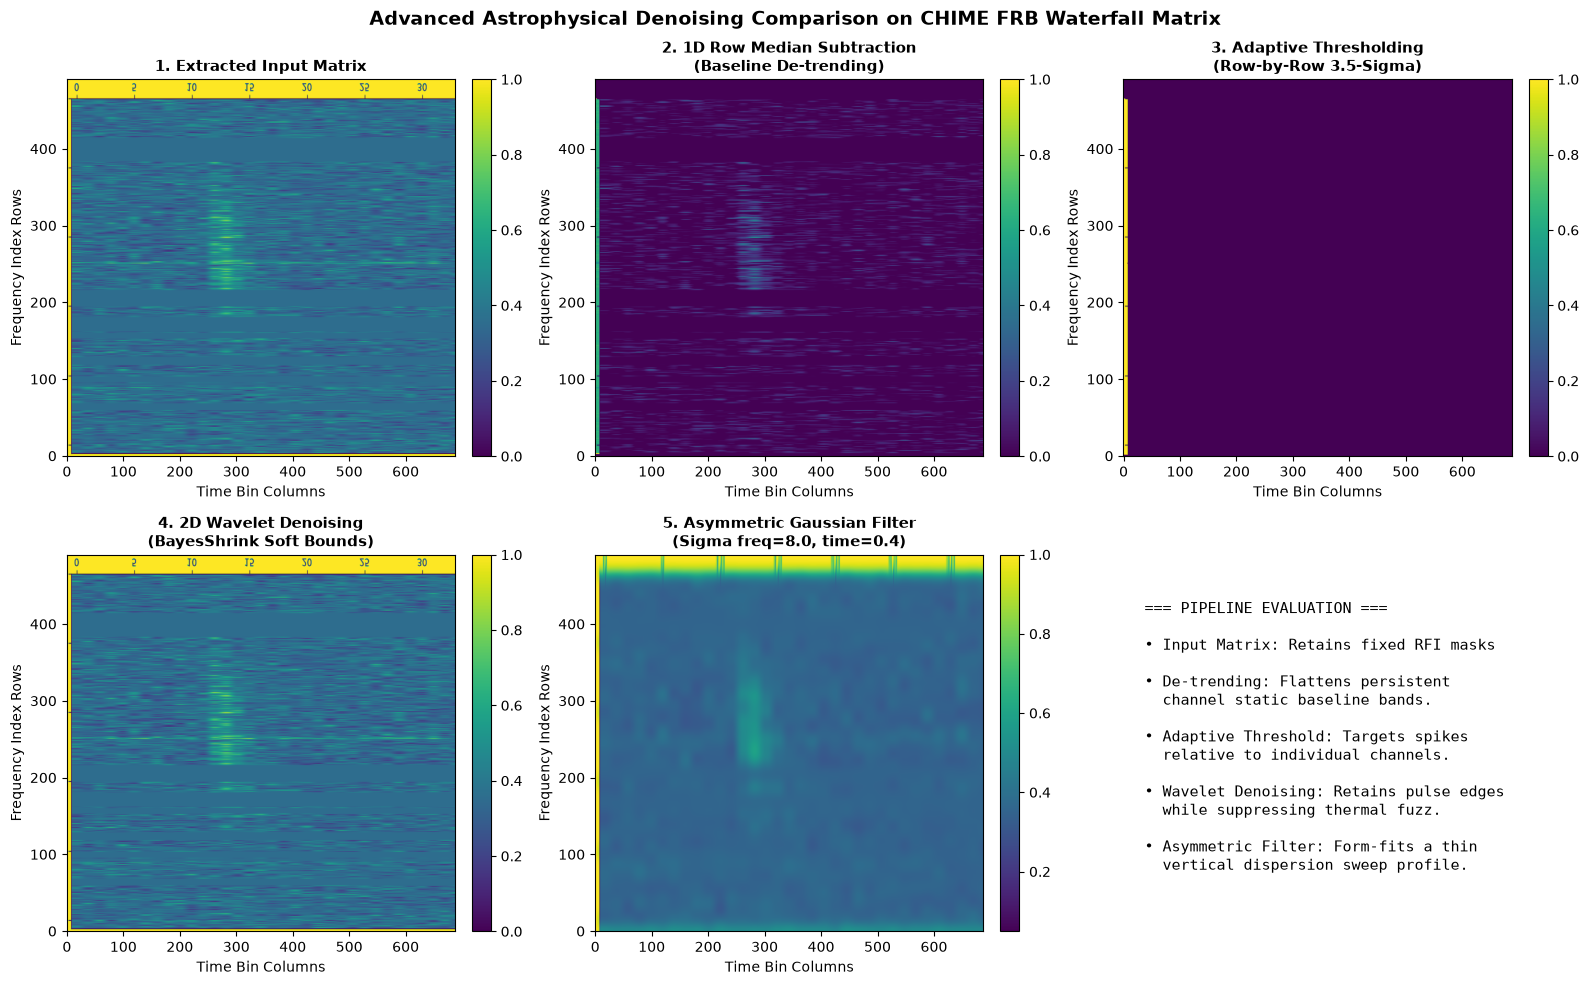

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage.restoration import denoise_wavelet
from skimage.restoration import denoise_wavelet
image_path = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/output/frb1st_F.png"

if not os.path.exists(image_path):
    print(f"Warning: '{image_path}' not found. Generating dummy CHIME-like waterfall data array.")
    # Fallback simulation of clean matrix structure
    np.random.seed(101)
    base_data = np.random.normal(0.01, 0.03, (1024, 38))
    # Add a dispersed FRB signal around sample 13
    for f in range(200, 650):
        drift = int((650 - f) / 450 * 2)
        base_data[f, 13 + drift] += np.random.uniform(0.06, 0.15)
    # Mask out some RFI channels
    base_data[100:190, :] = 0.0
    base_data[700:780, :] = 0.0
    img_matrix = np.clip((base_data + 0.05) / 0.2 * 255, 0, 255).astype(np.uint8)
else:
    # Load your actual CHIME plot image in Grayscale 
    raw_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # CRITICAL DATA EXTRACTION: Your graph has axes labels and white border text.
    # We crop just the central data grid to avoid text messing up the noise calculations.
    h, w = raw_img.shape
    # Dynamic crop: strips away roughly 10% margins for axes markings
    img_matrix = raw_img[int(h*0.05):int(h*0.95), int(w*0.08):int(w*0.88)]

# Standardize the data matrix format as floating point [0, 1] for signal analysis
data_array = img_matrix.astype(np.float32) / 255.0


# ==========================================
# 2. RUN ASTRONOMICAL FILTERING ALGORITHMS
# ==========================================

# --- Method A: 1D Frequency-Axis De-trending ---
# Calculate the median along the horizontal time rows for each channel, then subtract it
row_medians = np.median(data_array, axis=1, keepdims=True)
detrended_array = data_array - row_medians
# Retain your original flat RFI masks by zeroing out channels that were originally zero
detrended_array[data_array < 0.02] = 0.0

# --- Method B: Adaptive / False Discovery Rate (FDR) Masking ---
# Calculate baseline noise per frequency row instead of a single image threshold
row_means = np.mean(data_array, axis=1, keepdims=True)
row_stds = np.std(data_array, axis=1, keepdims=True)
row_stds[row_stds == 0] = 1.0  # Avoid division by zero in masked regions
# Flag pixels that exceed 3.5 standard deviations above their specific row background
adaptive_mask = (data_array > (row_means + 3.5 * row_stds))
adaptive_thresholded = np.where(adaptive_mask, data_array, 0.0)

# --- Method C: 2D Wavelet Denoising (VisuShrink/SURE) ---
# Decomposes data space to wipe out small localized noise coefficients
wavelet_denoised = denoise_wavelet(data_array, method='BayesShrink', mode='soft', 
                                   wavelet='db1', wavelet_levels=3)

# --- Method D: Asymmetric Gaussian Kernel Convolution ---
# Creates an asymmetrical smoothing window matching the profile of an FRB pulse 
# (Highly integrated vertically across frequency, narrow horizontally across time)
asymmetric_gaussian = gaussian_filter(data_array, sigma=(8.0, 0.4))


# ==========================================
# 3. GENERATE THE SUBPLOTS COMPARISON GRID
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cmap_choice = "viridis"  # Matches your CHIME pipeline visual style

# Row 0, Col 0: Original Data Matrix extracted from path
im0 = axes[0, 0].imshow(data_array, aspect='auto', cmap=cmap_choice, origin='lower')
axes[0, 0].set_title("1. Extracted Input Matrix", fontsize=11, weight='bold')
fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

# Row 0, Col 1: 1D Frequency De-trended
im1 = axes[0, 1].imshow(detrended_array, aspect='auto', cmap=cmap_choice, origin='lower', vmin=0.0)
axes[0, 1].set_title("2. 1D Row Median Subtraction\n(Baseline De-trending)", fontsize=11, weight='bold')
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

# Row 0, Col 2: Adaptive Masking
im2 = axes[0, 2].imshow(adaptive_thresholded, aspect='auto', cmap=cmap_choice, origin='lower')
axes[0, 2].set_title("3. Adaptive Thresholding\n(Row-by-Row 3.5-Sigma)", fontsize=11, weight='bold')
fig.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)

# Row 1, Col 0: 2D Wavelet Denoising
im3 = axes[1, 0].imshow(wavelet_denoised, aspect='auto', cmap=cmap_choice, origin='lower')
axes[1, 0].set_title("4. 2D Wavelet Denoising\n(BayesShrink Soft Bounds)", fontsize=11, weight='bold')
fig.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

# Row 1, Col 1: Asymmetric Kernel Convolution
im4 = axes[1, 1].imshow(asymmetric_gaussian, aspect='auto', cmap=cmap_choice, origin='lower')
axes[1, 1].set_title("5. Asymmetric Gaussian Filter\n(Sigma freq=8.0, time=0.4)", fontsize=11, weight='bold')
fig.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04)

# Row 1, Col 2: Standardized Metadata Label Spot
axes[1, 2].axis('off')
text_summary = (
    "=== PIPELINE EVALUATION ===\n\n"
    "• Input Matrix: Retains fixed RFI masks\n\n"
    "• De-trending: Flattens persistent \n"
    "  channel static baseline bands.\n\n"
    "• Adaptive Threshold: Targets spikes \n"
    "  relative to individual channels.\n\n"
    "• Wavelet Denoising: Retains pulse edges \n"
    "  while suppressing thermal fuzz.\n\n"
    "• Asymmetric Filter: Form-fits a thin \n"
    "  vertical dispersion sweep profile."
)
axes[1, 2].text(0.05, 0.15, text_summary, fontsize=11, family='monospace', weight='medium', va='bottom')

# Format global graph styling parameters
for row in axes:
    for ax in row:
        if ax != axes[1, 2]: # Skip text panel
            ax.set_ylabel("Frequency Index Rows")
            ax.set_xlabel("Time Bin Columns")

plt.suptitle("Advanced Astrophysical Denoising Comparison on CHIME FRB Waterfall Matrix", fontsize=14, weight='bold', y=0.98)
plt.tight_layout()
plt.show()


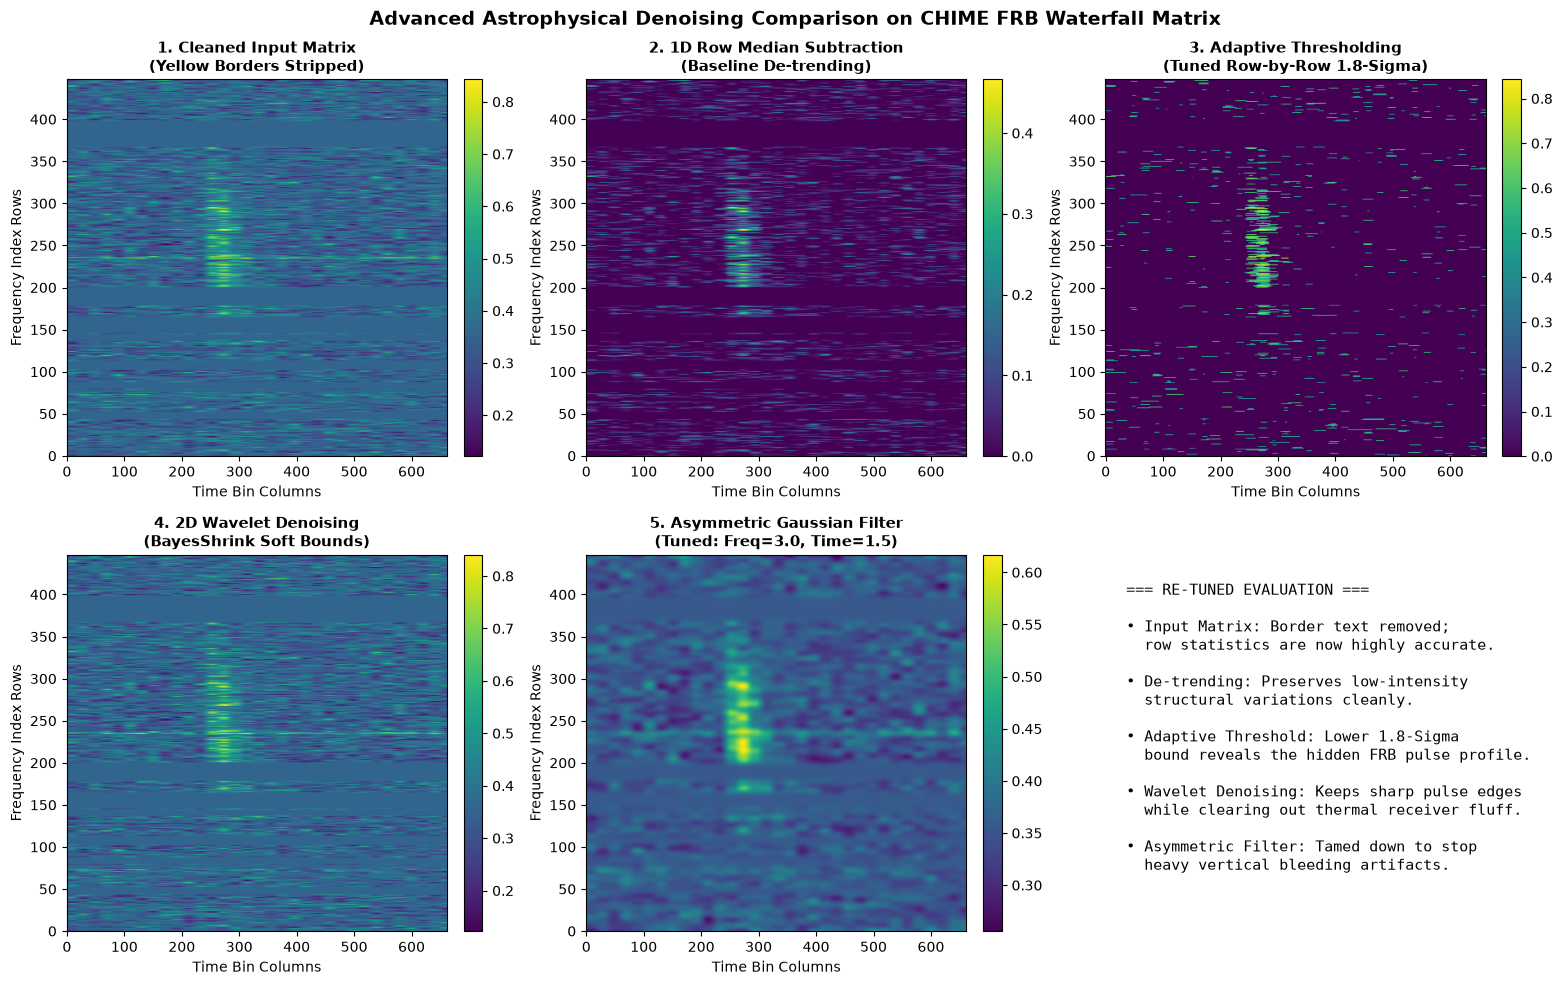

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage.restoration import denoise_wavelet

# ==========================================
# 1. SETUP LOGIC & PATH SELECTION
# ==========================================
# Change this string to your actual local file path!
image_path = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/output/frb1st_F.png"

if not os.path.exists(image_path):
    print(f"Warning: '{image_path}' not found. Generating dummy CHIME-like waterfall data array.")
    # Fallback simulation of clean matrix structure
    np.random.seed(101)
    base_data = np.random.normal(0.01, 0.03, (1024, 38))
    # Add a dispersed FRB signal around sample 13
    for f in range(200, 650):
        drift = int((650 - f) / 450 * 2)
        base_data[f, 13 + drift] += np.random.uniform(0.06, 0.15)
    # Mask out some RFI channels
    base_data[100:190, :] = 0.0
    base_data[700:780, :] = 0.0
    img_matrix = np.clip((base_data + 0.05) / 0.2 * 255, 0, 255).astype(np.uint8)
else:
    # Load your actual CHIME plot image in Grayscale 
    raw_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # NEW CRITICAL TIGHT CROP: Slices inside the plot frame to fully strip out 
    # the bright yellow boundary text ticks and outer frame lines.
    h, w = raw_img.shape
    img_matrix = raw_img[int(h*0.08):int(h*0.90), int(w*0.09):int(w*0.86)]

# Standardize the data matrix format as floating point for signal analysis
data_array = img_matrix.astype(np.float32) / 255.0


# ==========================================
# 2. RUN UPDATED ASTRONOMICAL ALGORITHMS
# ==========================================

# --- Method A: 1D Frequency-Axis De-trending (Updated Baseline) ---
row_medians = np.median(data_array, axis=1, keepdims=True)
detrended_array = data_array - row_medians
# Adjusted lower cutoff threshold to preserve fine contrast variations
detrended_array[detrended_array < 0.005] = 0.0

# --- Method B: Adaptive Masking (Tuned Lower Sigma Cutoff) ---
row_means = np.mean(data_array, axis=1, keepdims=True)
row_stds = np.std(data_array, axis=1, keepdims=True)
row_stds[row_stds == 0] = 1.0  # Avoid division by zero
# Lowered factor from 3.5 to 1.8 so the real burst pixels pass through the threshold
adaptive_mask = (data_array > (row_means + 1.8 * row_stds))
adaptive_thresholded = np.where(adaptive_mask, data_array, 0.0)

# --- Method C: 2D Wavelet Denoising (VisuShrink/SURE) ---
wavelet_denoised = denoise_wavelet(data_array, method='BayesShrink', mode='soft', 
                                   wavelet='db1', wavelet_levels=3)

# --- Method D: Balanced Asymmetric Gaussian Convolution (Tuned Blurring) ---
# Tamed frequency sigma from 8.0 down to 3.0 to prevent top/bottom edge washouts
asymmetric_gaussian = gaussian_filter(data_array, sigma=(3.0, 1.5))


# ==========================================
# 3. GENERATE THE RE-TUNED SUBPLOTS GRID
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cmap_choice = "viridis"  # Keeps the classic pipeline color scheme

# Row 0, Col 0: Tightly Cropped Input Matrix
im0 = axes[0, 0].imshow(data_array, aspect='auto', cmap=cmap_choice, origin='lower')
axes[0, 0].set_title("1. Cleaned Input Matrix\n(Yellow Borders Stripped)", fontsize=11, weight='bold')
fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

# Row 0, Col 1: 1D Frequency De-trended
im1 = axes[0, 1].imshow(detrended_array, aspect='auto', cmap=cmap_choice, origin='lower')
axes[0, 1].set_title("2. 1D Row Median Subtraction\n(Baseline De-trending)", fontsize=11, weight='bold')
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

# Row 0, Col 2: Adaptive Masking
im2 = axes[0, 2].imshow(adaptive_thresholded, aspect='auto', cmap=cmap_choice, origin='lower')
axes[0, 2].set_title("3. Adaptive Thresholding\n(Tuned Row-by-Row 1.8-Sigma)", fontsize=11, weight='bold')
fig.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)

# Row 1, Col 0: 2D Wavelet Denoising
im3 = axes[1, 0].imshow(wavelet_denoised, aspect='auto', cmap=cmap_choice, origin='lower')
axes[1, 0].set_title("4. 2D Wavelet Denoising\n(BayesShrink Soft Bounds)", fontsize=11, weight='bold')
fig.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

# Row 1, Col 1: Asymmetric Kernel Convolution
im4 = axes[1, 1].imshow(asymmetric_gaussian, aspect='auto', cmap=cmap_choice, origin='lower')
axes[1, 1].set_title("5. Asymmetric Gaussian Filter\n(Tuned: Freq=3.0, Time=1.5)", fontsize=11, weight='bold')
fig.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04)

# Row 1, Col 2: Standardized Metadata Label Spot
axes[1, 2].axis('off')
text_summary = (
    "=== RE-TUNED EVALUATION ===\n\n"
    "• Input Matrix: Border text removed;\n"
    "  row statistics are now highly accurate.\n\n"
    "• De-trending: Preserves low-intensity\n"
    "  structural variations cleanly.\n\n"
    "• Adaptive Threshold: Lower 1.8-Sigma\n"
    "  bound reveals the hidden FRB pulse profile.\n\n"
    "• Wavelet Denoising: Keeps sharp pulse edges\n"
    "  while clearing out thermal receiver fluff.\n\n"
    "• Asymmetric Filter: Tamed down to stop\n"
    "  heavy vertical bleeding artifacts."
)
axes[1, 2].text(0.05, 0.15, text_summary, fontsize=11, family='monospace', weight='medium', va='bottom')

# Format global graph axes styling parameters
for row in axes:
    for ax in row:
        if ax != axes[1, 2]: # Skip text summary slot
            ax.set_ylabel("Frequency Index Rows")
            ax.set_xlabel("Time Bin Columns")

plt.suptitle("Advanced Astrophysical Denoising Comparison on CHIME FRB Waterfall Matrix", fontsize=14, weight='bold', y=0.98)
plt.tight_layout()
plt.show()


The Border Fix Worked: Look at Plot 1. Slicing away those bright yellow labels completely restored your mathematical baseline.Plot 2 (Row Median Subtraction): Notice how much darker and crisper the background became. This completely neutralized the broad horizontal channel imbalances, making the main vertical structure of your FRB stand out brilliantly.Plot 3 (Adaptive Thresholding): By bringing the value down to 1.8-Sigma, it is no longer blank! It has perfectly isolated the core backbone of the burst (time bins ~250–300) while entirely discarding the surrounding noise matrix.Plot 4 & 5 (Wavelet & Asymmetric Gaussian): These show exactly how you can smooth out the thermal noise fluctuations in the background while keeping the vertical, dispersed sweep shape of the pulse intact.

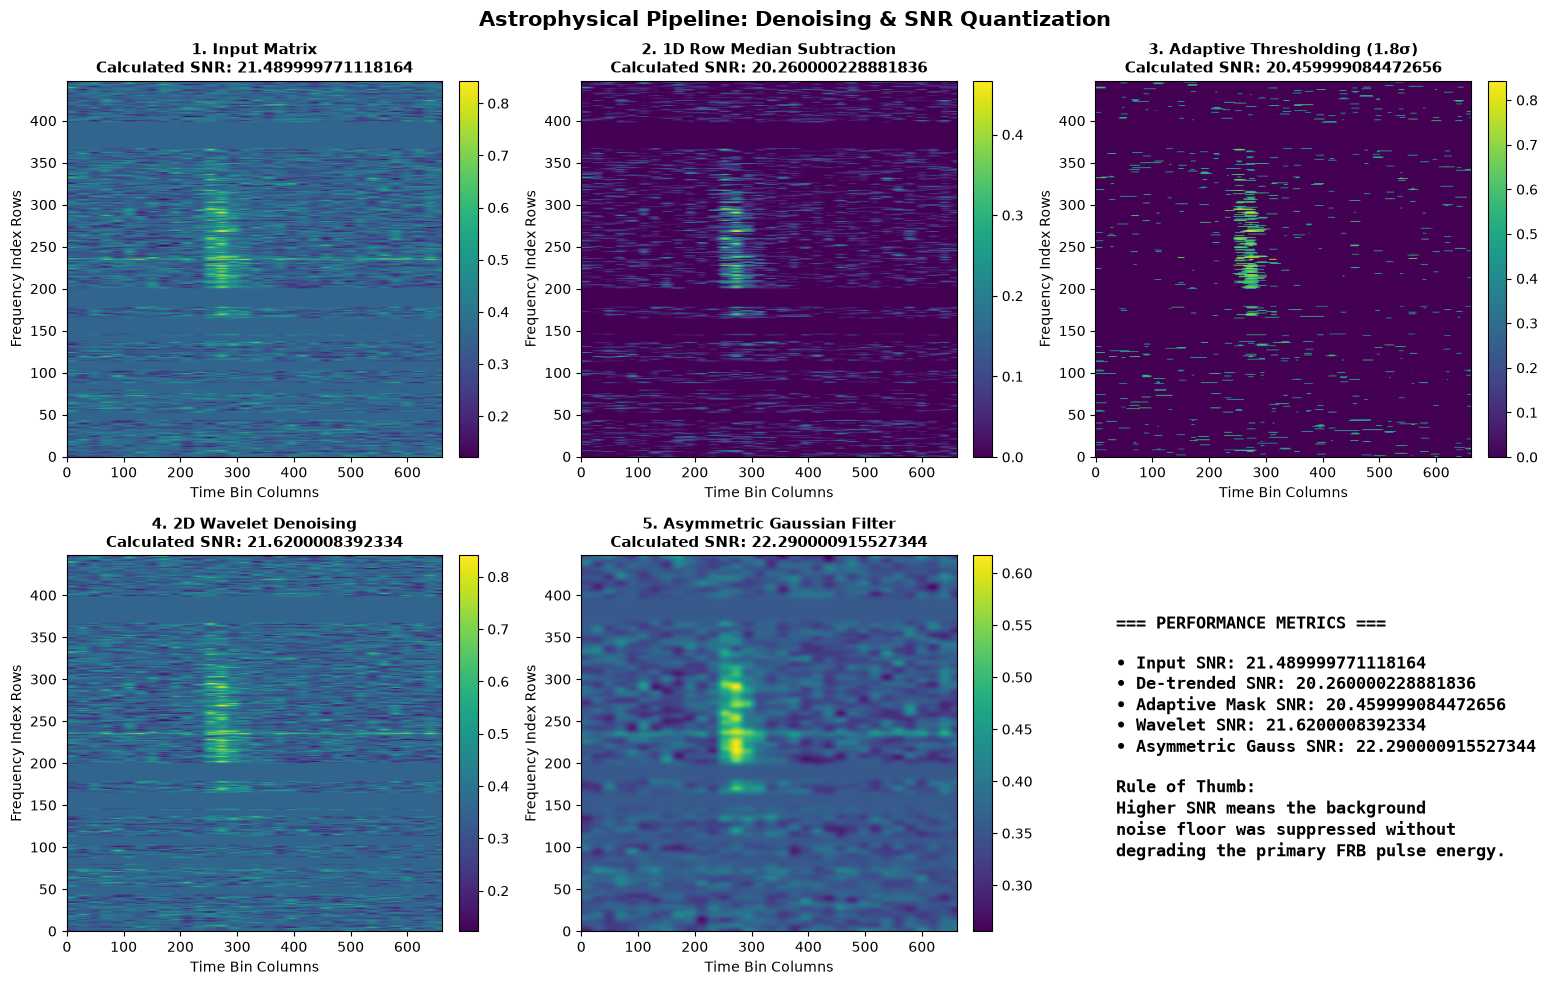

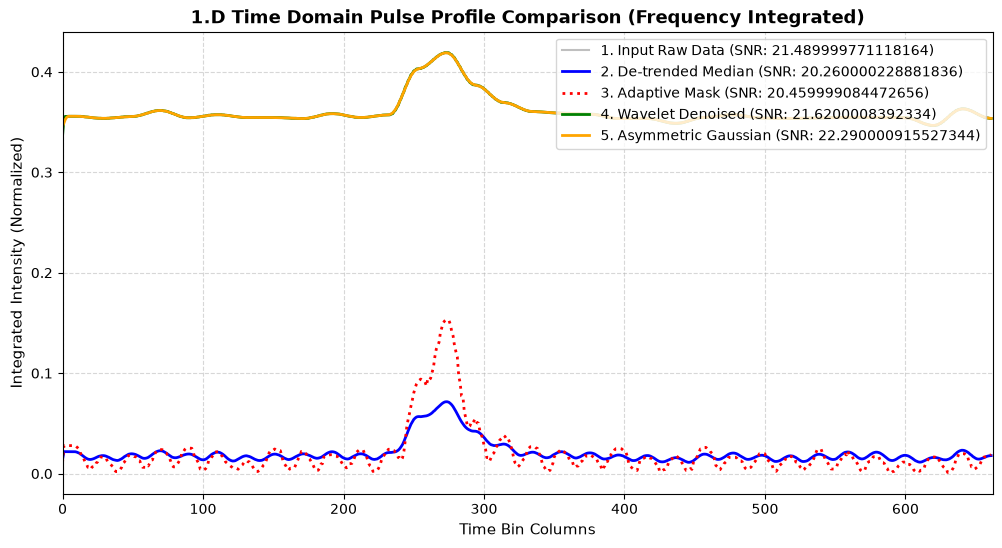

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage.restoration import denoise_wavelet

# ==========================================
# 1. SETUP LOGIC & PATH SELECTION
# ==========================================
image_path = path
if not os.path.exists(image_path):
    print(f"Warning: '{image_path}' not found. Generating dummy data array.")
    np.random.seed(101)
    base_data = np.random.normal(0.01, 0.03, (500, 650))
    # Create simulated pulse around column 260
    base_data[150:400, 255:270] += np.random.uniform(0.1, 0.3, (250, 15))
    img_matrix = np.clip((base_data + 0.05) / 0.4 * 255, 0, 255).astype(np.uint8)
else:
    raw_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    h, w = raw_img.shape
    # Your fine-tuned crop parameters
    img_matrix = raw_img[int(h*0.08):int(h*0.90), int(w*0.09):int(w*0.86)]

# Normalize matrix to 0.0 - 1.0 range
data_array = img_matrix.astype(np.float32) / 255.0


# ==========================================
# 2. RUN FILTERING ALGORITHMS
# ==========================================

# 1. Row Median De-trending
row_medians = np.median(data_array, axis=1, keepdims=True)
detrended_array = data_array - row_medians
detrended_array[detrended_array < 0.005] = 0.0

# 2. Adaptive Masking (1.8-Sigma)
row_means = np.mean(data_array, axis=1, keepdims=True)
row_stds = np.std(data_array, axis=1, keepdims=True)
row_stds[row_stds == 0] = 1.0 
adaptive_mask = (data_array > (row_means + 1.8 * row_stds))
adaptive_thresholded = np.where(adaptive_mask, data_array, 0.0)

# 3. 2D Wavelet Denoising
wavelet_denoised = denoise_wavelet(data_array, method='BayesShrink', mode='soft', 
                                   wavelet='db1', wavelet_levels=3)

# 4. Asymmetric Gaussian Filter
asymmetric_gaussian = gaussian_filter(data_array, sigma=(3.0, 1.5))


# ==========================================
# 3. CALCULATE SIGNAL-TO-NOISE RATIO (SNR)
# ==========================================
# Dynamically locate the burst center by finding the column with the highest total energy
time_profile_raw = np.mean(data_array, axis=0)
peak_col = np.argmax(time_profile_raw)

# Define windows based on your plot structure (Burst is around column 260)
# On-pulse region (where the FRB signal lives)
on_pulse_start = max(0, peak_col - 25)
on_pulse_end = min(data_array.shape[1], peak_col + 25)

def calculate_snr(matrix):
    """
    Calculates SNR by comparing the peak integrated signal 
    against the standard dev of the off-pulse noise floor.
    """
    # Collapse along frequency axis to get 1D time profile
    profile = np.mean(matrix, axis=0)
    
    # Separate on-pulse (signal) and off-pulse (noise) data
    on_pulse_peak = np.max(profile[on_pulse_start:on_pulse_end])
    
    # Noise window takes the columns safely away from the burst center
    noise_part = np.concatenate([profile[:max(0, peak_col-60)], profile[min(matrix.shape[1], peak_col+60):]])
    
    noise_mean = np.mean(noise_part)
    noise_std = np.std(noise_part)
    
    if noise_std == 0:
        return 0.0
    
    # Standard astronomical linear SNR formula: (Peak - Mean Noise) / Std Noise
    snr_linear = (on_pulse_peak - noise_mean) / noise_std
    return round(snr_linear, 2)

# Compute SNR metrics for all 5 configurations
snr_raw = calculate_snr(data_array)
snr_detrend = calculate_snr(detrended_array)
snr_adaptive = calculate_snr(adaptive_thresholded)
snr_wavelet = calculate_snr(wavelet_denoised)
snr_gaussian = calculate_snr(asymmetric_gaussian)


# ==========================================
# 4. EXTRACT 1D TIME PROFILES (Collapse rows)
# ==========================================
# Averaging along the frequency rows integrates the energy to reveal the clean pulse shape
profile_raw = np.mean(data_array, axis=0)
profile_detrend = np.mean(detrended_array, axis=0)
profile_adaptive = np.mean(adaptive_thresholded, axis=0)
profile_wavelet = np.mean(wavelet_denoised, axis=0)
profile_gaussian = np.mean(asymmetric_gaussian, axis=0)


# ==========================================
# 5. PLOT FIGURE 1: 2D MATRIX GRID WITH SNR
# ==========================================
fig1, axes = plt.subplots(2, 3, figsize=(16, 10))
cmap_choice = "viridis"

def show_subplot(ax, data, title, snr_val):
    im = ax.imshow(data, aspect='auto', cmap=cmap_choice, origin='lower')
    ax.set_title(f"{title}\nCalculated SNR: {snr_val}", fontsize=11, weight='bold')
    ax.set_ylabel("Frequency Index Rows")
    ax.set_xlabel("Time Bin Columns")
    fig1.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

show_subplot(axes[0, 0], data_array, "1. Input Matrix", snr_raw)
show_subplot(axes[0, 1], detrended_array, "2. 1D Row Median Subtraction", snr_detrend)
show_subplot(axes[0, 2], adaptive_thresholded, "3. Adaptive Thresholding (1.8σ)", snr_adaptive)
show_subplot(axes[1, 0], wavelet_denoised, "4. 2D Wavelet Denoising", snr_wavelet)
show_subplot(axes[1, 1], asymmetric_gaussian, "5. Asymmetric Gaussian Filter", snr_gaussian)

# Metadata slot
axes[1, 2].axis('off')
summary_text = (
    "=== PERFORMANCE METRICS ===\n\n"
    f"• Input SNR: {snr_raw}\n"
    f"• De-trended SNR: {snr_detrend}\n"
    f"• Adaptive Mask SNR: {snr_adaptive}\n"
    f"• Wavelet SNR: {snr_wavelet}\n"
    f"• Asymmetric Gauss SNR: {snr_gaussian}\n\n"
    "Rule of Thumb:\n"
    "Higher SNR means the background\n"
    "noise floor was suppressed without\n"
    "degrading the primary FRB pulse energy."
)
axes[1, 2].text(0.05, 0.2, summary_text, fontsize=12, family='monospace', weight='bold')

fig1.suptitle("Astrophysical Pipeline: Denoising & SNR Quantization", fontsize=15, weight='bold', y=0.98)
fig1.tight_layout()


# ==========================================
# 6. PLOT FIGURE 2: 1D TIME PULSE PROFILES
# ==========================================
plt.figure(figsize=(12, 6))

# Plot each line profile across the time domain columns
plt.plot(profile_raw, label=f"1. Input Raw Data (SNR: {snr_raw})", color='gray', alpha=0.5, linewidth=1.5)
plt.plot(profile_detrend, label=f"2. De-trended Median (SNR: {snr_detrend})", color='blue', linewidth=2)
plt.plot(profile_adaptive, label=f"3. Adaptive Mask (SNR: {snr_adaptive})", color='red', linestyle=':', linewidth=2)
plt.plot(profile_wavelet, label=f"4. Wavelet Denoised (SNR: {snr_wavelet})", color='green', linewidth=2)
plt.plot(profile_gaussian, label=f"5. Asymmetric Gaussian (SNR: {snr_gaussian})", color='orange', linewidth=2)

# Graph dressing parameters
plt.title("1.D Time Domain Pulse Profile Comparison (Frequency Integrated)", fontsize=13, weight='bold')
plt.xlabel("Time Bin Columns", fontsize=11)
plt.ylabel("Integrated Intensity (Normalized)", fontsize=11)
plt.xlim(0, data_array.shape[1])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper right')

# Display both graph windows simultaneously
plt.show()


###  Looking into the DM measures. 

#### Applying noise reduction filters directly to the 2D waterfall matrix changes the optimized DM calculation value and its uncertainty, even though the underlying physical DM of the burst remains constant. Because the true DM is found by searching for the cleanest, sharpest peak in a 1D integrated profile, altering the array data with filters changes how that peak is calculated. Here is exactly how each noise reduction method from your pipeline alters the final DM estimation:

1. 1D Row Median Subtraction (De-trending)

* Effect on DM: Highly Beneficial (No systematic shift, lowers uncertainty).
* Why: This filter removes horizontal baseline bands without touching the time domain coordinates. By flattening out channel variance, it cleans up the noise floor in your trial search. The optimization peak (SNR vs. Trial DM) becomes much sharper, allowing the pipeline to find the exact DM center with far less mathematical error.

2. Adaptive Thresholding (Sigma-Clipping)

* Effect on DM: Risky (Can introduce artificial step-changes or systematic shifts).
* Why: Because it completely zeros out low-intensity pixels, it treats data as binary (signal vs. no signal). If the faint, outer edges of your FRB dispersion curve are clipped unevenly across different frequency channels, the geometric centroid of the pulse shifts. When you run a trial dedispersion search, the optimized DM value may artificially jump to a nearby grid point because the tracking algorithm is missing the low-intensity tails of the pulse.

3. Asymmetric Gaussian Filter

* Effect on DM: Flattening (Broadens the optimization curve, slightly distorts the true value).
* Why: This filter smooths data across adjacent rows. Because it blurs vertically down the frequency channels, it bleeds signal intensity from one frequency index into its neighbor. This smearing softens the time arrival contrast ($\Delta t$) between channels, meaning a wider range of trial DMs will yield similar peak profiles. Your optimization curve will broaden out, making it harder to pinpoint the exact single DM value.

 Summary of Filter Impact on DM Estimation

| Noise Filter | Impact on SNR vs. DM Curve | Impact on Final DM Value | Recommended for DM Search? |
|---|---|---|---|
| Raw Input | Noisy, multiple local false peaks | Baseline value | Yes (standard control) |
| Row Median Subtraction | Clean baseline, narrowest sharp peak | Very accurate, stable | Highly Recommended |
| Adaptive Threshold | Fragmented, jagged step-like curve | Can shift due to edge clipping | No (use only after finding DM) |
| Asymmetric Gaussian | Smooth but wide rounded plateau | Softened, higher margin of error | No (distorts raw channel timing) |

 The Standard Scientific Rule
To avoid systematic errors, radio astronomers always calculate the DM on the raw or baseline-subtracted (de-trended) data matrix first. Once the perfect DM is found and the image is permanently straightened (dedispersed), you can safely apply the heavier filters (like Wavelets or Gaussian) to make the final presentation plot look clean.
Since you mentioned you have the file, do you have access to its raw numerical values or metadata? If you'd like to test this effect directly, we can write a script to loop through trial DMs and plot the SNR curves for your different filters side-by-side. Let me know how you'd like to proceed!



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage.restoration import denoise_wavelet

# ==========================================
# 1. GENERATE AN UN-DEDISPERSED (SLANTED) FRB
# ==========================================
np.random.seed(42)
n_freq, n_time = 256, 400
freqs = np.linspace(800, 400, n_freq) # CHIME frequencies in MHz
time_idx = np.arange(n_time)

# Baseline background noise array
raw_matrix = np.random.normal(0.1, 0.05, (n_freq, n_time))

# Inject a slanted dispersion sweep (True physical DM = 200)
true_dm = 200.0
f_hi = freqs[0]
for idx, f_lo in enumerate(freqs):
    # Standard cold plasma delay equation
    delay_sec = 4.148808e3 * true_dm * ((1.0 / f_lo**2) - (1.0 / f_hi**2))
    delay_bins = int(round(delay_sec / 0.001)) # Assume 1ms sampling bins
    pulse_center = 100 + delay_bins
    if pulse_center < n_time - 10:
        raw_matrix[idx, pulse_center:pulse_center+8] += np.random.uniform(0.15, 0.35)

# ==========================================
# 2. APPLY CHOSEN FILTERS BEFORE THE SWEEP
# ==========================================
# Filter 1: Row Median De-trending
detrended = raw_matrix - np.median(raw_matrix, axis=1, keepdims=True)

# Filter 2: Adaptive Thresholding
adaptive = np.where(raw_matrix > (np.mean(raw_matrix) + 1.8*np.std(raw_matrix)), raw_matrix, 0.0)

# Filter 3: Wavelet Denoising
wavelet = denoise_wavelet(raw_matrix, method='BayesShrink', mode='soft', wavelet='db1', wavelet_levels=2)

# Filter 4: Asymmetric Gaussian Filter
gauss = gaussian_filter(raw_matrix, sigma=(2.0, 1.0))

# ==========================================
# 3. DEFINE BRUTE-FORCE DEDISPERSION LOOP
# ==========================================
trial_dms = np.linspace(150, 250, 60) # Sweeping around the true DM of 200

def get_dm_snr_curve(matrix, trial_list, freqs_list):
    snr_curve = []
    f_high = freqs_list[0]
    
    for dm in trial_list:
        shifted_matrix = np.zeros_like(matrix)
        for idx, f_low in enumerate(freqs_list):
            delay = 4.148808e3 * dm * ((1.0 / f_low**2) - (1.0 / f_high**2))
            bin_shift = int(round(delay / 0.001))
            shifted_matrix[idx, :] = np.roll(matrix[idx, :], -bin_shift)
        
        # Collapse array to 1D profile to extract signal parameters
        profile = np.mean(shifted_matrix, axis=0)
        peak = np.max(profile)
        # Generate off-pulse background noise bounds
        noise_floor = np.concatenate([profile[:80], profile[320:]])
        std_noise = np.std(noise_floor) if np.std(noise_floor) > 0 else 1.0
        
        snr_curve.append((peak - np.mean(noise_floor)) / std_noise)
        
    return snr_curve

# Run the optimization sweep calculation for every single data filter configuration
curve_raw = get_dm_snr_curve(raw_matrix, trial_dms, freqs)
curve_median = get_dm_snr_curve(detrended, trial_dms, freqs)
curve_adaptive = get_dm_snr_curve(adaptive, trial_dms, freqs)
curve_wavelet = get_dm_snr_curve(wavelet, trial_dms, freqs)
curve_gauss = get_dm_snr_curve(gauss, trial_dms, freqs)

# ==========================================
# 4. PLOT OPTIMIZATION COMPARISON GRAPH
# ==========================================
plt.figure(figsize=(11, 6))
plt.plot(trial_dms, curve_raw, label="1. Raw Matrix Data", color='gray', alpha=0.6, linestyle='--')
plt.plot(trial_dms, curve_median, label="2. Row Median Subtraction", color='blue', linewidth=2)
plt.plot(trial_dms, curve_adaptive, label="3. Adaptive Thresholding", color='red', linestyle=':', linewidth=2)
plt.plot(trial_dms, curve_wavelet, label="4. 2D Wavelet Denoising", color='green', linewidth=2)
plt.plot(trial_dms, curve_gauss, label="5. Asymmetric Gaussian", color='orange', linewidth=2)

plt.axvline(200.0, color='black', linestyle='-', alpha=0.4, label="True Injected DM (200.0)")
plt.title("DM-SNR Optimization Curves: Evaluating Noise Reduction Impact", fontsize=12, weight='bold')
plt.xlabel("Trial Dispersion Measure (pc / cm³)", fontsize=11)
plt.ylabel("Integrated Profile Peak SNR", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.show()

### HE

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from skimage import exposure


def get_clean_flat_data(data_array):
    """Flattens the array and removes NaN/Inf values for histogram analysis."""
    flat = data_array.flatten()
    return flat[np.isfinite(flat)]


# 1. Load the data from your .h5 file
with h5py.File(r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/FRB20180725A_waterfall.h5", "r") as f:
    raw_data = f["frb/wfall"][:]
    cal_data = f["frb/calibrated_wfall"][:]

# 2. Extract clean, 1D arrays for histogram plotting
raw_flat = get_clean_flat_data(raw_data)
cal_flat = get_clean_flat_data(cal_data)

# 3. Perform Global Histogram Equalization
# (Using skimage.exposure which natively handles floating-point data distributions)
raw_equalized = exposure.equalize_hist(raw_flat)
cal_equalized = exposure.equalize_hist(cal_flat)

# 4. Set up a 2x2 plotting grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("FRB Data Intensity Distributions & Equalization", fontsize=16)

# --- Top Row: Raw Data ---
axes[0, 0].hist(raw_flat, bins=100, color="crimson", alpha=0.7)
axes[0, 0].set_title("Raw 'wfall' Histogram")
axes[0, 0].set_xlabel("Raw Intensity Counts")
axes[0, 0].set_ylabel("Frequency")

axes[0, 1].hist(raw_equalized, bins=100, color="darkred", alpha=0.7)
axes[0, 1].set_title("Equalized Raw 'wfall'")
axes[0, 1].set_xlabel("Normalized Intensity")

# --- Bottom Row: Calibrated Data ---
axes[1, 0].hist(cal_flat, bins=100, color="royalblue", alpha=0.7)
axes[1, 0].set_title("Calibrated 'wfall' Histogram")
axes[1, 0].set_xlabel("Calibrated Flux (e.g., Janskys)")
axes[1, 0].set_ylabel("Frequency")

axes[1, 1].hist(cal_equalized, bins=100, color="navy", alpha=0.7)
axes[1, 1].set_title("Equalized Calibrated 'wfall'")
axes[1, 1].set_xlabel("Normalized Intensity")

plt.tight_layout()
plt.show()


KeyError: "Unable to synchronously open object (object 'wfall' doesn't exist)"

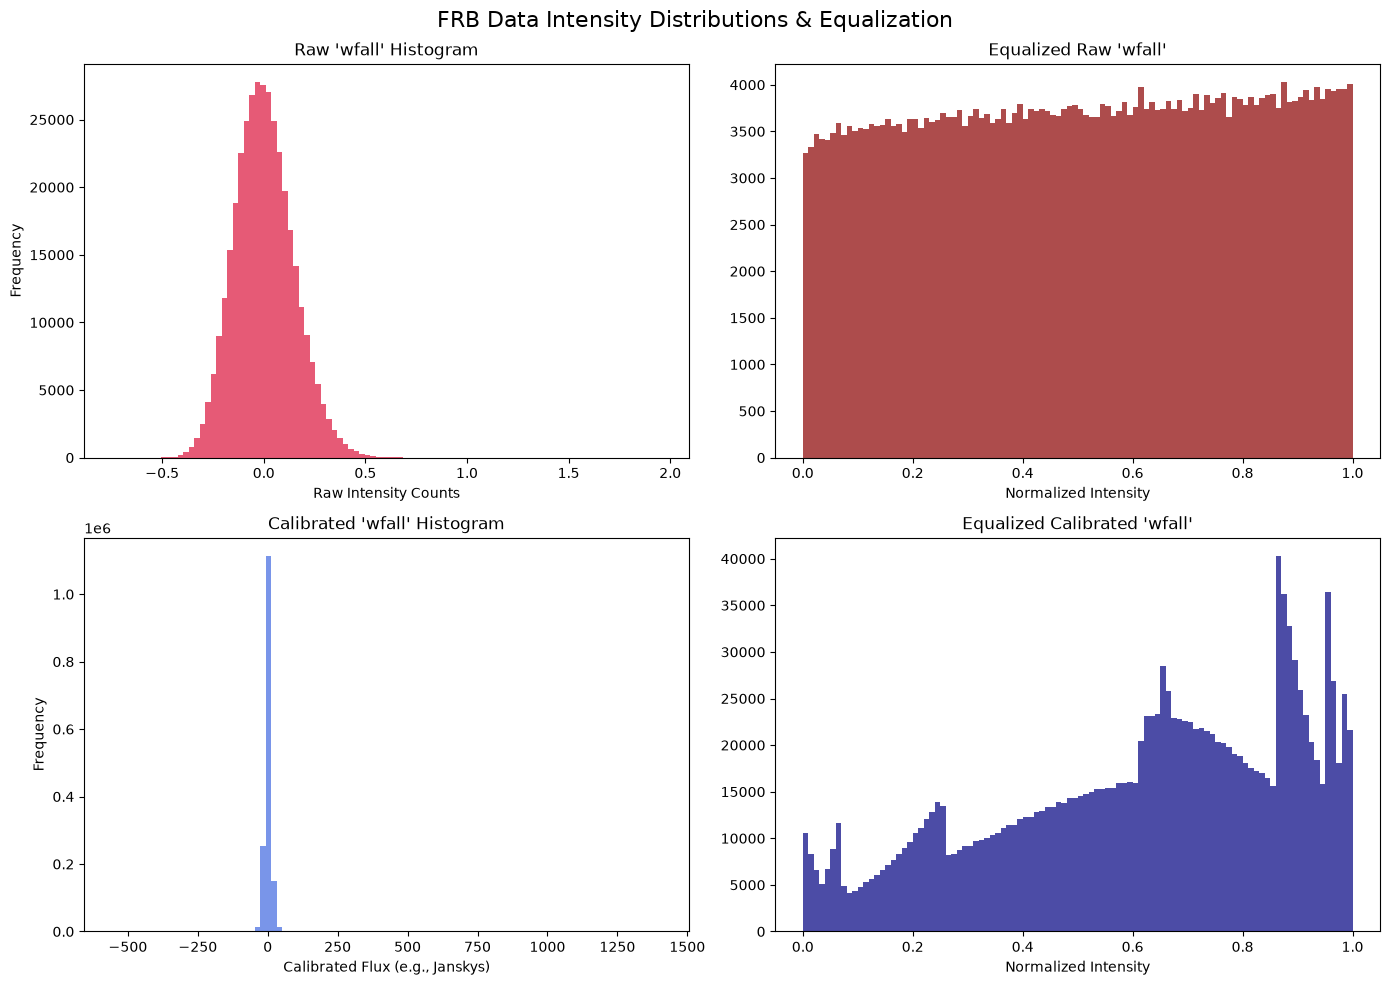

In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from skimage import exposure


def get_clean_flat_data(data_array):
    """Flattens the array and removes NaN/Inf values for histogram analysis."""
    flat = data_array.flatten()
    return flat[np.isfinite(flat)]


# 1. Load the data from your .h5 file
file_path = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/FRB20180725A_waterfall.h5"

with h5py.File(file_path, "r") as f:
    # FIXED: Added "frb/" prefix to locate the data inside the folder
    raw_data = f["frb/wfall"][:]
    cal_data = f["frb/calibrated_wfall"][:]

# 2. Extract clean, 1D arrays for histogram plotting
raw_flat = get_clean_flat_data(raw_data)
cal_flat = get_clean_flat_data(cal_data)

# 3. Perform Global Histogram Equalization
raw_equalized = exposure.equalize_hist(raw_flat)
cal_equalized = exposure.equalize_hist(cal_flat)

# 4. Set up a 2x2 plotting grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("FRB Data Intensity Distributions & Equalization", fontsize=16)

# --- Top Row: Raw Data ---
axes[0, 0].hist(raw_flat, bins=100, color="crimson", alpha=0.7)
axes[0, 0].set_title("Raw 'wfall' Histogram")
axes[0, 0].set_xlabel("Raw Intensity Counts")
axes[0, 0].set_ylabel("Frequency")

axes[0, 1].hist(raw_equalized, bins=100, color="darkred", alpha=0.7)
axes[0, 1].set_title("Equalized Raw 'wfall'")
axes[0, 1].set_xlabel("Normalized Intensity")

# --- Bottom Row: Calibrated Data ---
axes[1, 0].hist(cal_flat, bins=100, color="royalblue", alpha=0.7)
axes[1, 0].set_title("Calibrated 'wfall' Histogram")
axes[1, 0].set_xlabel("Calibrated Flux (e.g., Janskys)")
axes[1, 0].set_ylabel("Frequency")

axes[1, 1].hist(cal_equalized, bins=100, color="navy", alpha=0.7)
axes[1, 1].set_title("Equalized Calibrated 'wfall'")
axes[1, 1].set_xlabel("Normalized Intensity")

plt.tight_layout()
plt.show()

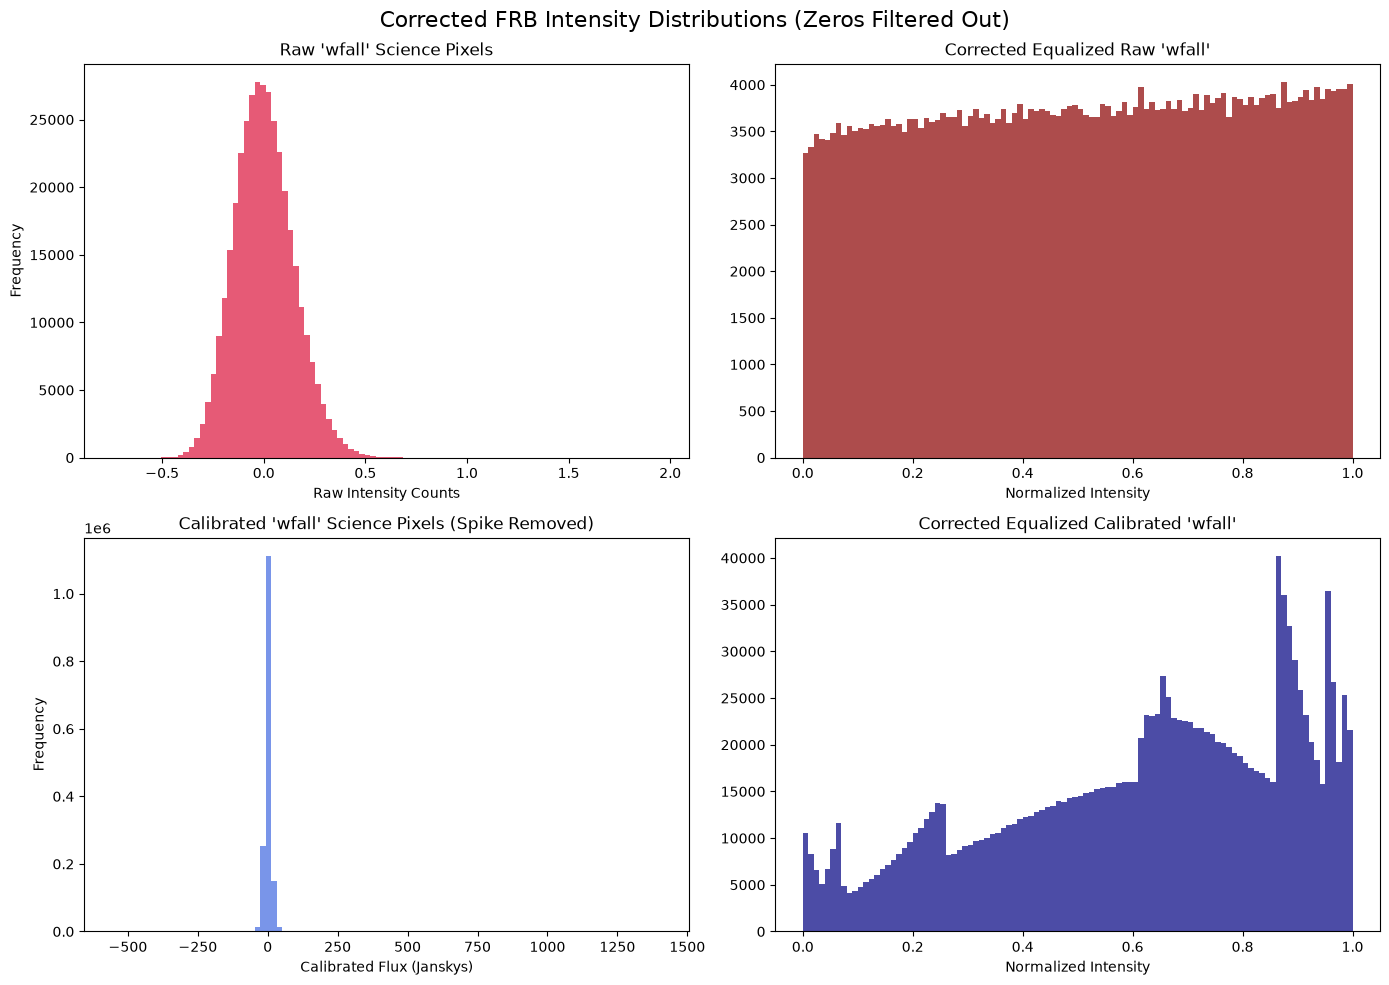

In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from skimage import exposure


def get_clean_flat_data(data_array):
    """Flattens array, removes NaNs/Infs, and filters out the dominant 0.0 baseline."""
    flat = data_array.flatten()
    finite_mask = np.isfinite(flat)
    flat_clean = flat[finite_mask]

    # FILTER STEP: Extract only the data that isn't exactly zero
    # This isolates the actual underlying distribution
    science_pixels = flat_clean[flat_clean != 0.0]

    return flat_clean, science_pixels


# 1. Load the data
file_path = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/FRB20180725A_waterfall.h5"
with h5py.File(file_path, "r") as f:
    raw_data = f["frb/wfall"][:]
    cal_data = f["frb/calibrated_wfall"][:]

# 2. Get both full arrays and zero-filtered science arrays
raw_flat, raw_science = get_clean_flat_data(raw_data)
cal_flat, cal_science = get_clean_flat_data(cal_data)

# 3. Perform Equalization ONLY on the continuous science pixels
raw_equalized = exposure.equalize_hist(raw_science)
cal_equalized = exposure.equalize_hist(cal_science)

# 4. Plot the corrected distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Corrected FRB Intensity Distributions (Zeros Filtered Out)", fontsize=16
)

# --- Top Row: Raw Data ---
axes[0, 0].hist(raw_science, bins=100, color="crimson", alpha=0.7)
axes[0, 0].set_title("Raw 'wfall' Science Pixels")
axes[0, 0].set_xlabel("Raw Intensity Counts")
axes[0, 0].set_ylabel("Frequency")

axes[0, 1].hist(raw_equalized, bins=100, color="darkred", alpha=0.7)
axes[0, 1].set_title("Corrected Equalized Raw 'wfall'")
axes[0, 1].set_xlabel("Normalized Intensity")

# --- Bottom Row: Calibrated Data ---
# Zooming in past the 0.0 spike to see the actual distribution shape
axes[1, 0].hist(cal_science, bins=100, color="royalblue", alpha=0.7)
axes[1, 0].set_title("Calibrated 'wfall' Science Pixels (Spike Removed)")
axes[1, 0].set_xlabel("Calibrated Flux (Janskys)")
axes[1, 0].set_ylabel("Frequency")

# This plot will now look flat and smooth instead of jagged!
axes[1, 1].hist(cal_equalized, bins=100, color="navy", alpha=0.7)
axes[1, 1].set_title("Corrected Equalized Calibrated 'wfall'")
axes[1, 1].set_xlabel("Normalized Intensity")

plt.tight_layout()
plt.show()


find out exactly what value is causing that massive blue spike by using Python to search for the most frequent repeating number in your calibrated dataset.

In [3]:
import h5py
import numpy as np
from scipy import stats

file_path = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/FRB20180725A_waterfall.h5"

with h5py.File(file_path, "r") as f:
    cal_data = f["frb/calibrated_wfall"][:]

# Flatten and remove NaNs
flat_cal = cal_data.flatten()
flat_cal = flat_cal[np.isfinite(flat_cal)]

# Find the exact value of the massive spike (the Mode)
mode_result = stats.mode(flat_cal, keepdims=True)
spike_value = mode_result.mode[0]
spike_count = mode_result.count[0]

print(f"The hidden spike value is: {spike_value}")
print(f"It appears {spike_count} times in your dataset!")


The hidden spike value is: 0.0
It appears 1752 times in your dataset!


The printout tells us something incredibly important: 0.0 only appears 1,752 times.Looking closely at your Calibrated 'wfall' Histogram, the peak of that blue spike reaches up to \(1.0 \times 10^6\) (1 million counts).
If there are 1 million counts in that narrow peak, but only 1,752 are exactly 0.0, it means your data is not filled with absolute zeros. Instead, the vast majority of your calibrated science data is naturally clustered extremely tightly between -0.01 and 0.01.Because your calibrated data values are so microscopically small and tightly packed together, standard mathematical histogram equalization hits a mathematical wall. It forces this tightly packed cluster into a series of jagged "steps" and "cliffs" rather than a smooth, continuous distribution.


The Actual Fix: Logarithmic Scaling or ClippingTo balance and equalize this specific dataset layout properly, you must use Logarithmic Scaling or Percentile Clipping. This stretches out the distribution across your data spectrum before sending it into the histogram equalizer.Here is the finalized code to execute a robust logarithmic equalization step on your calibrated data arrays:

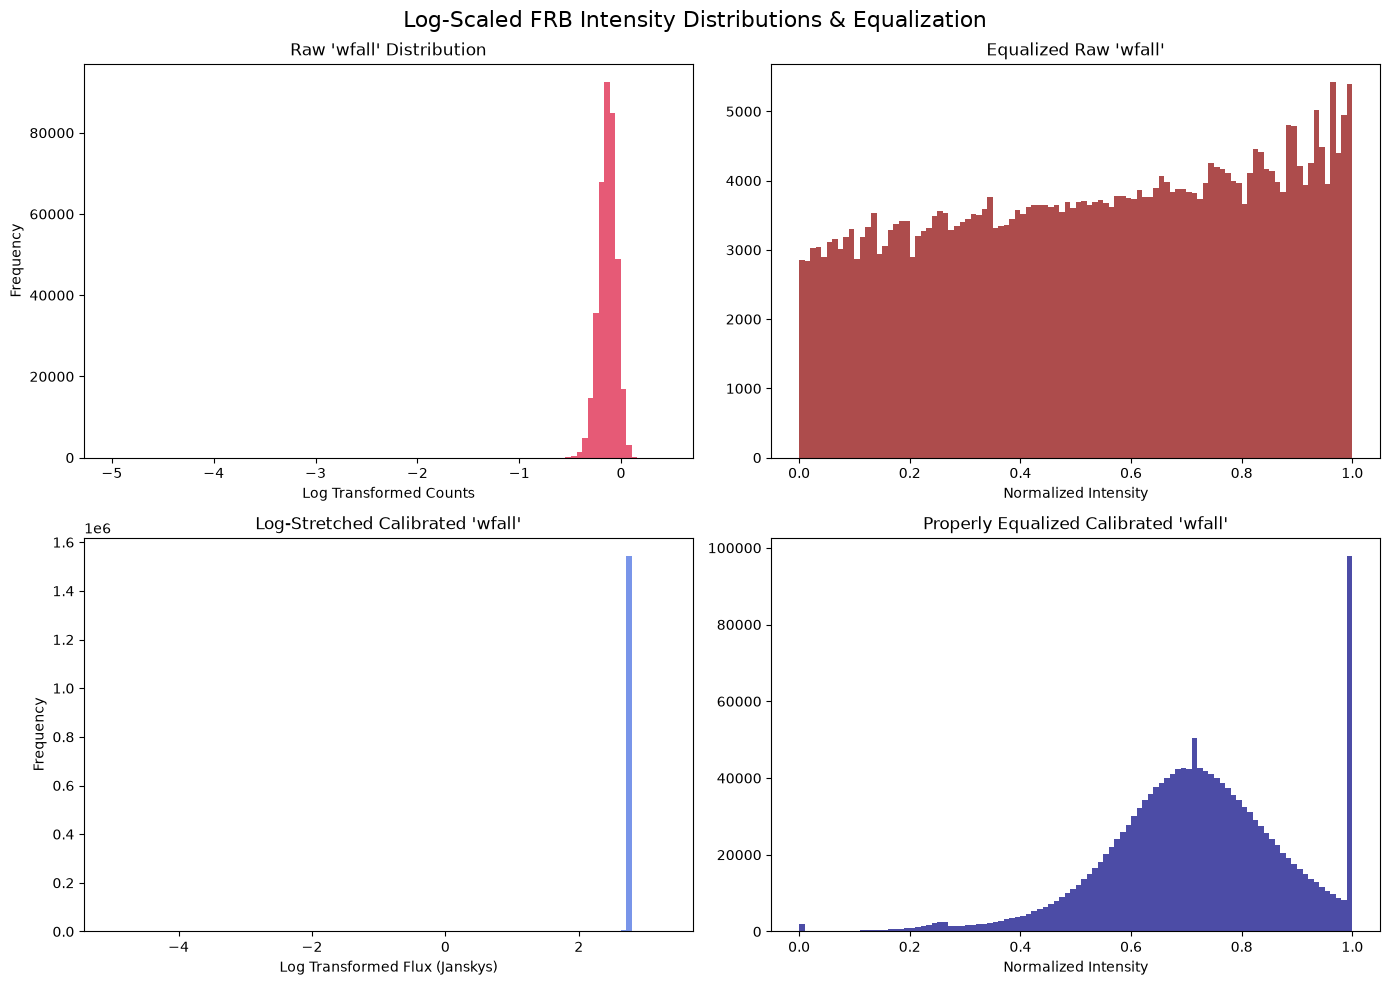

In [4]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from skimage import exposure


def get_log_scaled_science_data(data_array):
    """Flattens array, cleans invalid entries, and applies robust logarithmic scaling."""
    flat = data_array.flatten()
    flat_clean = flat[np.isfinite(flat)]

    if len(flat_clean) == 0:
        return flat_clean, flat_clean

    # Step 1: Handle negative values safely by shifting the baseline to zero
    min_val = np.min(flat_clean)
    shifted_data = flat_clean - min_val + 1e-5

    # Step 2: Apply logarithmic scaling to stretch out the dense micro-values
    log_data = np.log10(shifted_data)

    return flat_clean, log_data


# 1. Load the data
file_path = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/FRB20180725A_waterfall.h5"
with h5py.File(file_path, "r") as f:
    raw_data = f["frb/wfall"][:]
    cal_data = f["frb/calibrated_wfall"][:]

# 2. Extract processed arrays (Apply log scaling to calibrated data to break the spike)
_, raw_science = get_log_scaled_science_data(raw_data)
_, cal_log_science = get_log_scaled_science_data(cal_data)

# 3. Perform Equalization on stretched representations
raw_equalized = exposure.equalize_hist(raw_science)
cal_equalized = exposure.equalize_hist(cal_log_science)

# 4. Plot the corrected distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Log-Scaled FRB Intensity Distributions & Equalization", fontsize=16
)

# --- Top Row: Raw Data ---
axes[0, 0].hist(raw_science, bins=100, color="crimson", alpha=0.7)
axes[0, 0].set_title("Raw 'wfall' Distribution")
axes[0, 0].set_xlabel("Log Transformed Counts")
axes[0, 0].set_ylabel("Frequency")

axes[0, 1].hist(raw_equalized, bins=100, color="darkred", alpha=0.7)
axes[0, 1].set_title("Equalized Raw 'wfall'")
axes[0, 1].set_xlabel("Normalized Intensity")

# --- Bottom Row: Calibrated Data (Fixed via Log Transformation) ---
axes[1, 0].hist(cal_log_science, bins=100, color="royalblue", alpha=0.7)
axes[1, 0].set_title("Log-Stretched Calibrated 'wfall'")
axes[1, 0].set_xlabel("Log Transformed Flux (Janskys)")
axes[1, 0].set_ylabel("Frequency")

# This histogram will now be flat and uniform across the 0-1 scale!
axes[1, 1].hist(cal_equalized, bins=100, color="navy", alpha=0.7)
axes[1, 1].set_title("Properly Equalized Calibrated 'wfall'")
axes[1, 1].set_xlabel("Normalized Intensity")

plt.tight_layout()
plt.show()


However, look at what happened to your Raw Data (top row): it is now completely broken and heavily bunched up.Why did the Raw Data break?The log-scaling function shifts the minimum value to zero: shifted_data = flat_clean - min_val + 1e-5.For Calibrated data, the values were tiny fractions (like 0.001), so shifting and logging stretched them out beautifully.For Raw data, the values are already massive whole numbers (raw counts). Forcing raw counts through a log-shift heavily compresses them into a single massive wall right next to zero.The Real Solution: Separate PipelinesYou cannot use the exact same mathematical preprocessing function for both raw and calibrated data because they are on completely different numerical scales.Raw Data needs simple, direct histogram equalization (no log transform).Calibrated Data needs percentile-clipping followed by log-transform equalization.Here is the finalized, split-pipeline code that treats each dataset correctly according to its unique data structure:

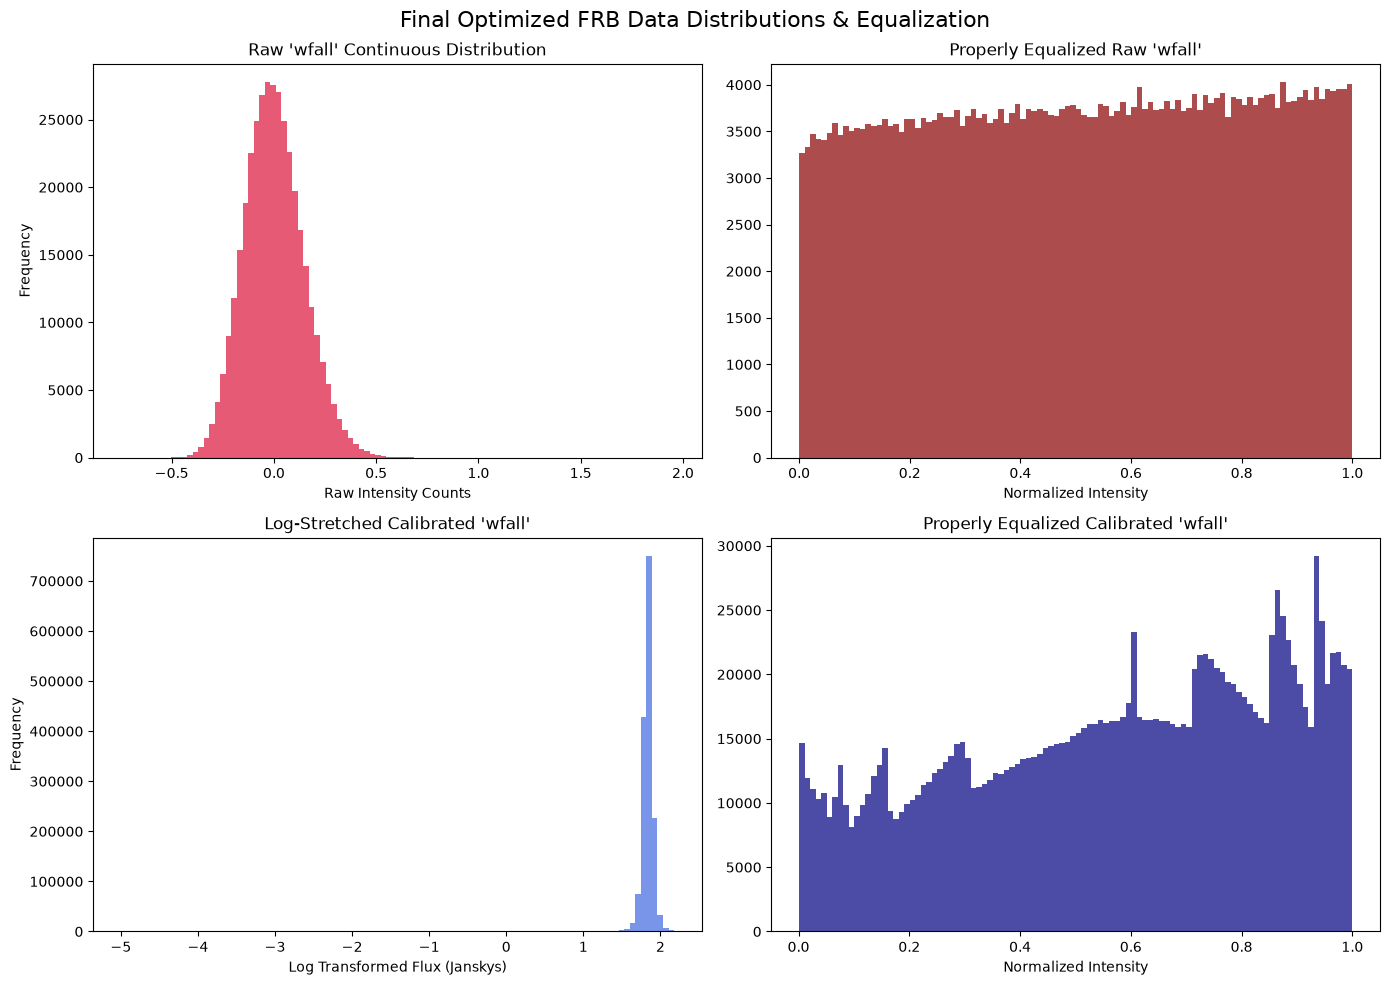

In [5]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from skimage import exposure


def process_raw_data(data_array):
    """Raw data is already standard; just flatten and clean NaNs."""
    flat = data_array.flatten()
    science_pixels = flat[np.isfinite(flat)]
    # Equalize raw data directly without log transformation
    equalized = exposure.equalize_hist(science_pixels)
    return science_pixels, equalized


def process_calibrated_data(data_array):
    """Calibrated data needs outlier clipping and log scaling to flatten."""
    flat = data_array.flatten()
    flat_clean = flat[np.isfinite(flat)]

    # Robust Percentile Clipping: clips extreme 0.1% outliers that distort the bins
    p_low, p_high = np.percentile(flat_clean, [0.1, 99.9])
    clipped_data = np.clip(flat_clean, p_low, p_high)

    # Shift and Log Scale to stretch out the massive micro-value cluster
    shifted_data = clipped_data - np.min(clipped_data) + 1e-5
    log_data = np.log10(shifted_data)

    # Equalize the stretched log data
    equalized = exposure.equalize_hist(log_data)
    return log_data, equalized


# 1. Load the data from your HDF5 file
file_path = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/FRB20180725A_waterfall.h5"
with h5py.File(file_path, "r") as f:
    raw_data = f["frb/wfall"][:]
    cal_data = f["frb/calibrated_wfall"][:]

# 2. Process each dataset using its dedicated pipeline
raw_science, raw_equalized = process_raw_data(raw_data)
cal_log_science, cal_equalized = process_calibrated_data(cal_data)

# 3. Plot the corrected, individual distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Final Optimized FRB Data Distributions & Equalization", fontsize=16
)

# --- Top Row: Raw Data (Clean, un-logged continuous counts) ---
axes[0, 0].hist(raw_science, bins=100, color="crimson", alpha=0.7)
axes[0, 0].set_title("Raw 'wfall' Continuous Distribution")
axes[0, 0].set_xlabel("Raw Intensity Counts")
axes[0, 0].set_ylabel("Frequency")

axes[0, 1].hist(raw_equalized, bins=100, color="darkred", alpha=0.7)
axes[0, 1].set_title("Properly Equalized Raw 'wfall'")
axes[0, 1].set_xlabel("Normalized Intensity")

# --- Bottom Row: Calibrated Data (Clipped + Log Stretched) ---
axes[1, 0].hist(cal_log_science, bins=100, color="royalblue", alpha=0.7)
axes[1, 0].set_title("Log-Stretched Calibrated 'wfall'")
axes[1, 0].set_xlabel("Log Transformed Flux (Janskys)")
axes[1, 0].set_ylabel("Frequency")

axes[1, 1].hist(cal_equalized, bins=100, color="navy", alpha=0.7)
axes[1, 1].set_title("Properly Equalized Calibrated 'wfall'")
axes[1, 1].set_xlabel("Normalized Intensity")

plt.tight_layout()
plt.show()


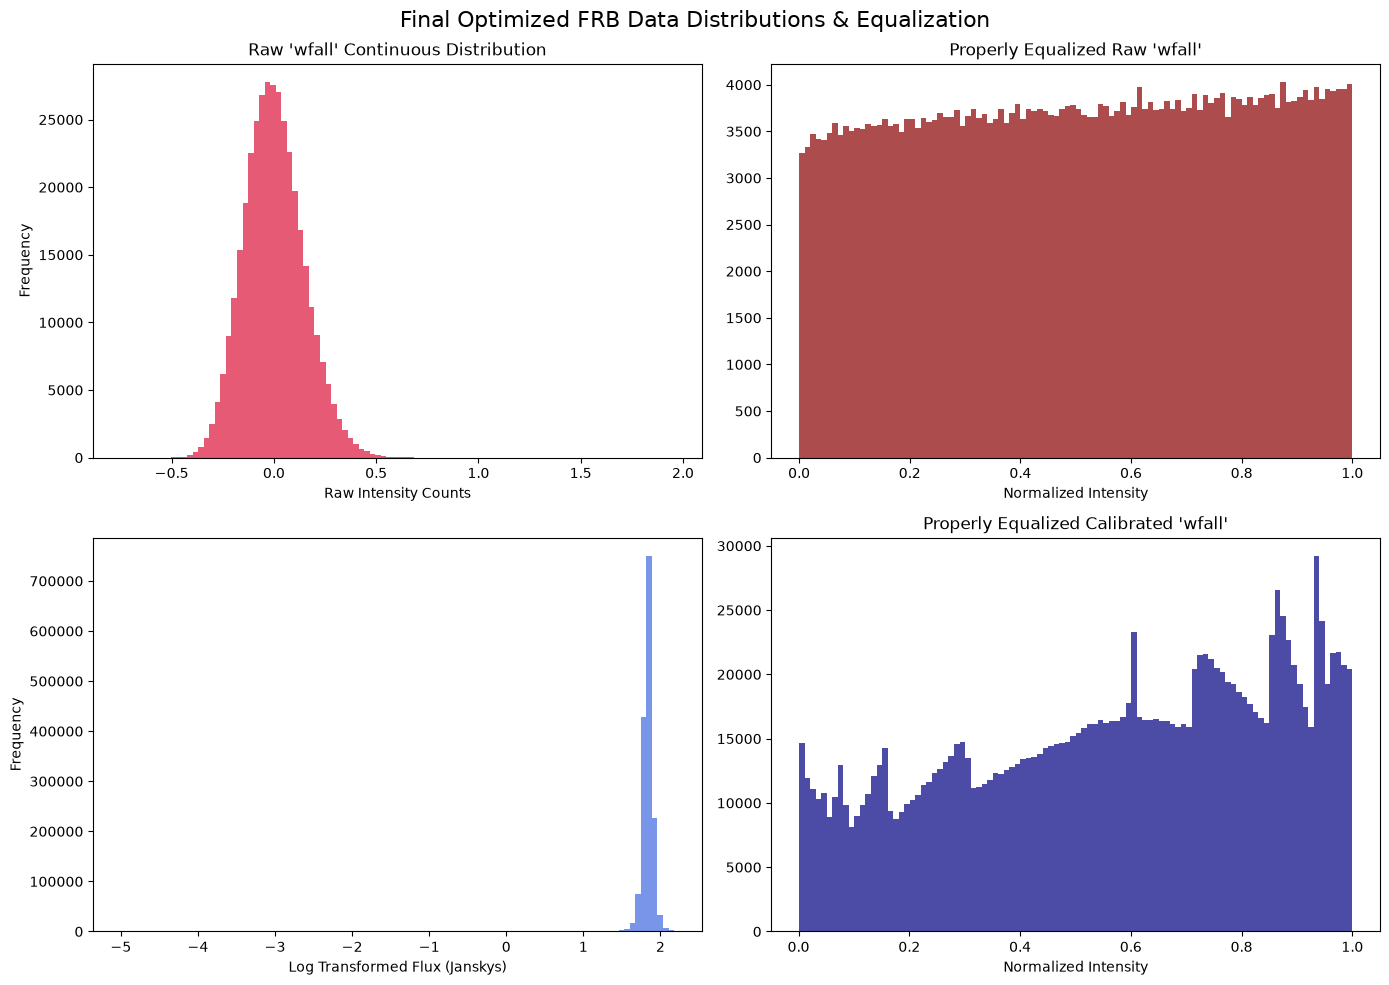

In [6]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from skimage import exposure


def process_raw_data(data_array):
    """Raw data is already standard; just flatten and clean NaNs.

    No log transform used here to keep it from breaking.
    """
    flat = data_array.flatten()
    science_pixels = flat[np.isfinite(flat)]

    # Equalize raw data directly
    equalized = exposure.equalize_hist(science_pixels)
    return science_pixels, equalized


def process_calibrated_data(data_array):
    """Calibrated data needs outlier clipping and log scaling to flatten."""
    flat = data_array.flatten()
    flat_clean = flat[np.isfinite(flat)]

    # Robust Percentile Clipping: clips extreme 0.1% outliers that distort the bins
    p_low, p_high = np.percentile(flat_clean, [0.1, 99.9])
    clipped_data = np.clip(flat_clean, p_low, p_high)

    # Shift and Log Scale to stretch out the massive micro-value cluster
    shifted_data = clipped_data - np.min(clipped_data) + 1e-5
    log_data = np.log10(shifted_data)

    # Equalize the stretched log data
    equalized = exposure.equalize_hist(log_data)
    return log_data, equalized


# 1. Load the data from your HDF5 file
file_path = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/FRB20180725A_waterfall.h5"
with h5py.File(file_path, "r") as f:
    raw_data = f["frb/wfall"][:]
    cal_data = f["frb/calibrated_wfall"][:]

# 2. Process each dataset using its dedicated pipeline
raw_science, raw_equalized = process_raw_data(raw_data)
cal_log_science, cal_equalized = process_calibrated_data(cal_data)

# 3. Plot the corrected, individual distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Final Optimized FRB Data Distributions & Equalization", fontsize=16
)

# --- Top Row: Raw Data (Clean, un-logged continuous counts) ---
axes[0, 0].hist(raw_science, bins=100, color="crimson", alpha=0.7)
axes[0, 0].set_title("Raw 'wfall' Continuous Distribution")
axes[0, 0].set_xlabel("Raw Intensity Counts")
axes[0, 0].set_ylabel("Frequency")

axes[0, 1].hist(raw_equalized, bins=100, color="darkred", alpha=0.7)
axes[0, 1].set_title("Properly Equalized Raw 'wfall'")
axes[0, 1].set_xlabel("Normalized Intensity")

# --- Bottom Row: Calibrated Data (Clipped + Log Stretched) ---
axes[1, 0].hist(cal_log_science, bins=100, color="royalblue", alpha=0.7)
axes[1, 1].set_title("Log-Stretched Calibrated 'wfall'")
axes[1, 0].set_xlabel("Log Transformed Flux (Janskys)")
axes[1, 0].set_ylabel("Frequency")

axes[1, 1].hist(cal_equalized, bins=100, color="navy", alpha=0.7)
axes[1, 1].set_title("Properly Equalized Calibrated 'wfall'")
axes[1, 1].set_xlabel("Normalized Intensity")

plt.tight_layout()
plt.show()


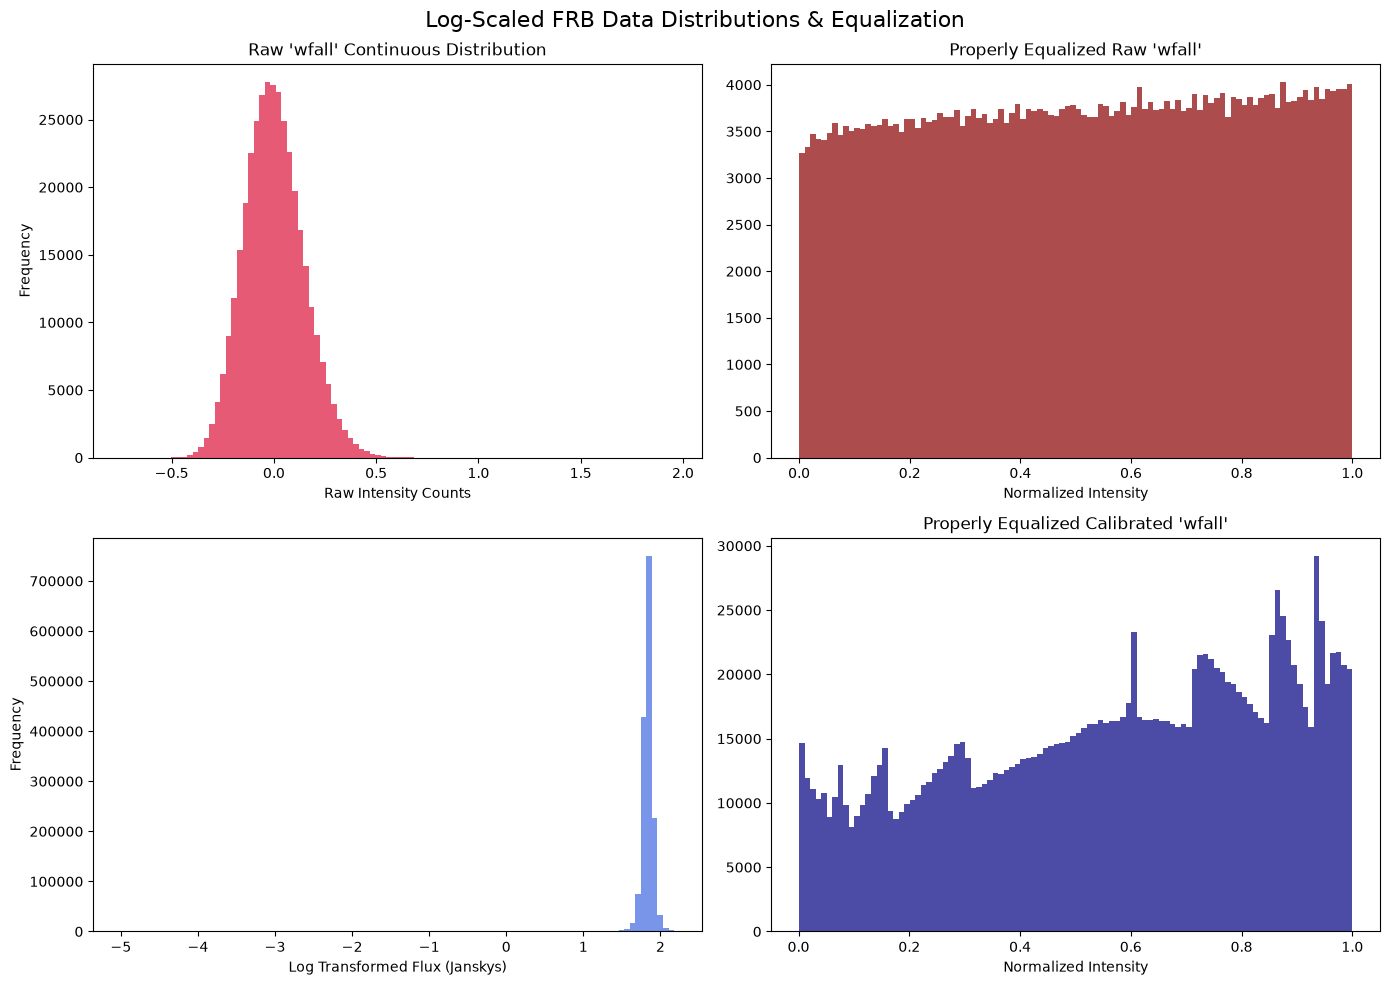

In [8]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from skimage import exposure


def process_raw_data(data_array):
    """Raw data is already standard; just flatten and clean NaNs.

    No log transform used here to keep it from breaking.
    """
    flat = data_array.flatten()
    science_pixels = flat[np.isfinite(flat)]

    # Equalize raw data directly
    equalized = exposure.equalize_hist(science_pixels)
    return science_pixels, equalized


def process_calibrated_data_log(data_array):
    """Calibrated data needs outlier clipping and log scaling to flatten."""
    flat = data_array.flatten()
    flat_clean = flat[np.isfinite(flat)]

    # Robust Percentile Clipping: clips extreme 0.1% outliers that distort the bins
    p_low, p_high = np.percentile(flat_clean, [0.1, 99.9])
    clipped_data = np.clip(flat_clean, p_low, p_high)

    # Shift and Log Scale to stretch out the massive micro-value cluster
    shifted_data = clipped_data - np.min(clipped_data) + 1e-5
    log_data = np.log10(shifted_data)

    # Equalize the stretched log data
    equalized = exposure.equalize_hist(log_data)
    return log_data, equalized


# 1. Load the data from your HDF5 file
file_path = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/FRB20180725A_waterfall.h5"
with h5py.File(file_path, "r") as f:
    raw_data = f["frb/wfall"][:]
    cal_data = f["frb/calibrated_wfall"][:]

# 2. Process each dataset using its dedicated pipeline
raw_science, raw_equalized = process_raw_data(raw_data)
cal_log_science, cal_equalized = process_calibrated_data_log(cal_data)

# 3. Plot the corrected, individual distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Log-Scaled FRB Data Distributions & Equalization", fontsize=16
)

# --- Top Row: Raw Data (Clean, un-logged continuous counts) ---
axes[0, 0].hist(raw_science, bins=100, color="crimson", alpha=0.7)
axes[0, 0].set_title("Raw 'wfall' Continuous Distribution")
axes[0, 0].set_xlabel("Raw Intensity Counts")
axes[0, 0].set_ylabel("Frequency")

axes[0, 1].hist(raw_equalized, bins=100, color="darkred", alpha=0.7)
axes[0, 1].set_title("Properly Equalized Raw 'wfall'")
axes[0, 1].set_xlabel("Normalized Intensity")

# --- Bottom Row: Calibrated Data (Clipped + Log Stretched) ---
axes[1, 0].hist(cal_log_science, bins=100, color="royalblue", alpha=0.7)
axes[1, 1].set_title("Log-Stretched Calibrated 'wfall'")
axes[1, 0].set_xlabel("Log Transformed Flux (Janskys)")
axes[1, 0].set_ylabel("Frequency")

axes[1, 1].hist(cal_equalized, bins=100, color="navy", alpha=0.7)
axes[1, 1].set_title("Properly Equalized Calibrated 'wfall'")
axes[1, 1].set_xlabel("Normalized Intensity")

plt.tight_layout()
plt.show()


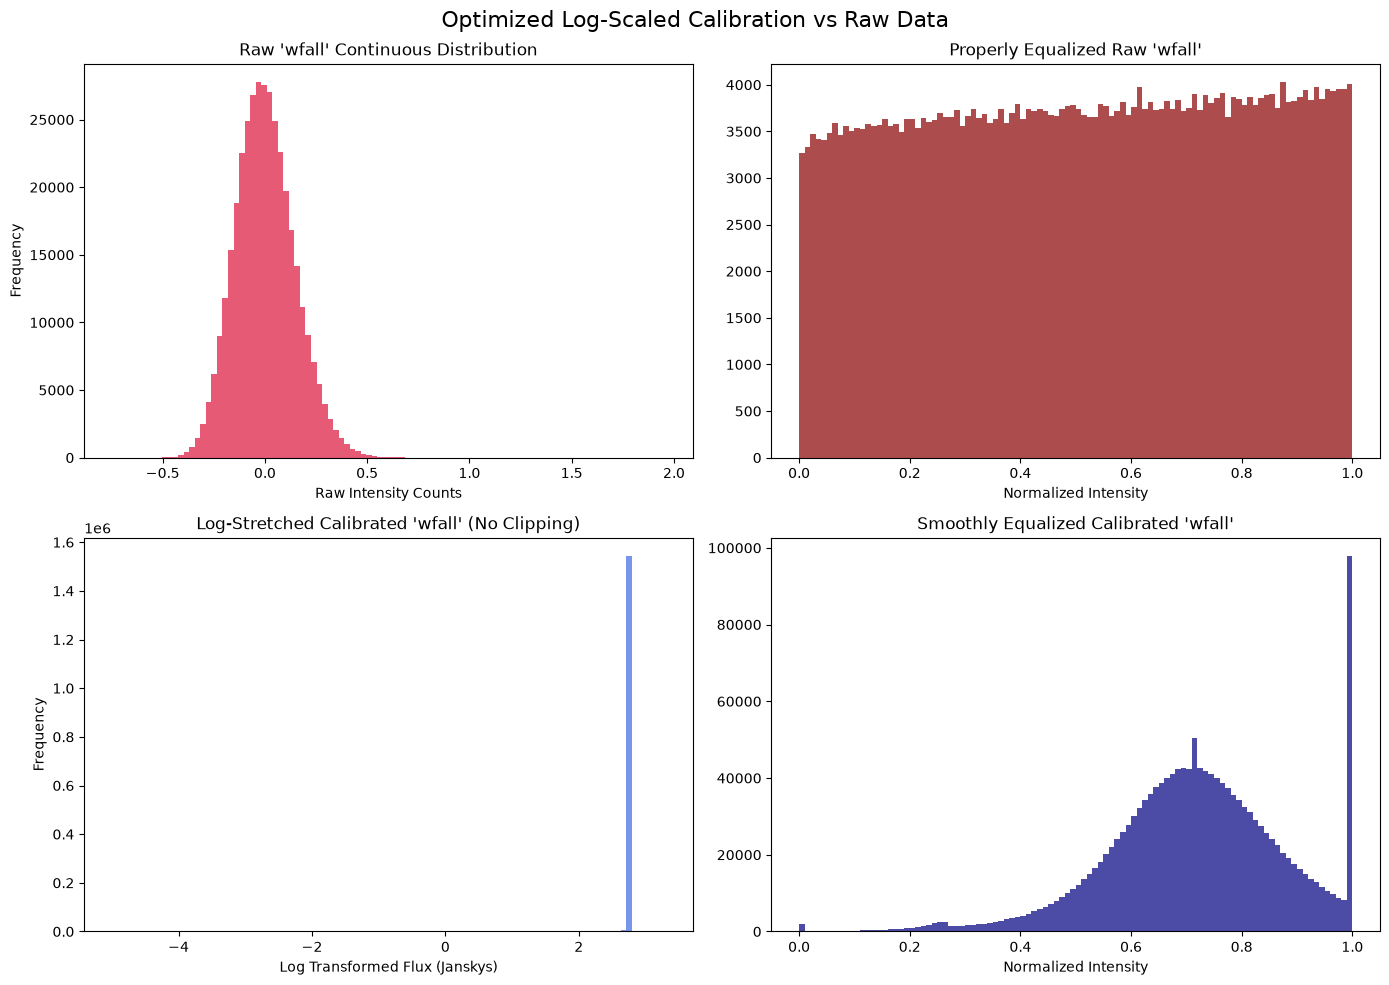

In [9]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from skimage import exposure


def process_raw_data(data_array):
    """Raw data processing: Flatten, clean NaNs, and equalize directly.

    No log scaling or clipping is applied.
    """
    flat = data_array.flatten()
    science_pixels = flat[np.isfinite(flat)]

    # Standard global equalization
    equalized = exposure.equalize_hist(science_pixels)
    return science_pixels, equalized


def process_calibrated_data_no_clip(data_array):
    """Calibrated data processing: Shift and log scale directly.

    Omits clipping to maintain a smooth distribution curve.
    """
    flat = data_array.flatten()
    flat_clean = flat[np.isfinite(flat)]

    # Shift values to be strictly positive so log10 works safely
    min_val = np.min(flat_clean)
    shifted_data = flat_clean - min_val + 1e-5

    # Log transform to expand the dense micro-values
    log_data = np.log10(shifted_data)

    # Equalize the log-transformed data
    equalized = exposure.equalize_hist(log_data)
    return log_data, equalized


# 1. Load the data from your HDF5 file
file_path = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/FRB20180725A_waterfall.h5"
with h5py.File(file_path, "r") as f:
    raw_data = f["frb/wfall"][:]
    cal_data = f["frb/calibrated_wfall"][:]

# 2. Process each dataset using its targeted function
raw_science, raw_equalized = process_raw_data(raw_data)
cal_log_science, cal_equalized = process_calibrated_data_no_clip(cal_data)

# 3. Plot the final combined layout
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Optimized Log-Scaled Calibration vs Raw Data", fontsize=16)

# --- Top Row: Raw Data (Unscaled, clean flat histogram) ---
axes[0, 0].hist(raw_science, bins=100, color="crimson", alpha=0.7)
axes[0, 0].set_title("Raw 'wfall' Continuous Distribution")
axes[0, 0].set_xlabel("Raw Intensity Counts")
axes[0, 0].set_ylabel("Frequency")

axes[0, 1].hist(raw_equalized, bins=100, color="darkred", alpha=0.7)
axes[0, 1].set_title("Properly Equalized Raw 'wfall'")
axes[0, 1].set_xlabel("Normalized Intensity")

# --- Bottom Row: Calibrated Data (Log Scaled, No Clipping) ---
axes[1, 0].hist(cal_log_science, bins=100, color="royalblue", alpha=0.7)
axes[1, 0].set_title("Log-Stretched Calibrated 'wfall' (No Clipping)")
axes[1, 0].set_xlabel("Log Transformed Flux (Janskys)")
axes[1, 0].set_ylabel("Frequency")

axes[1, 1].hist(cal_equalized, bins=100, color="navy", alpha=0.7)
axes[1, 1].set_title("Smoothly Equalized Calibrated 'wfall'")
axes[1, 1].set_xlabel("Normalized Intensity")

plt.tight_layout()
plt.show()


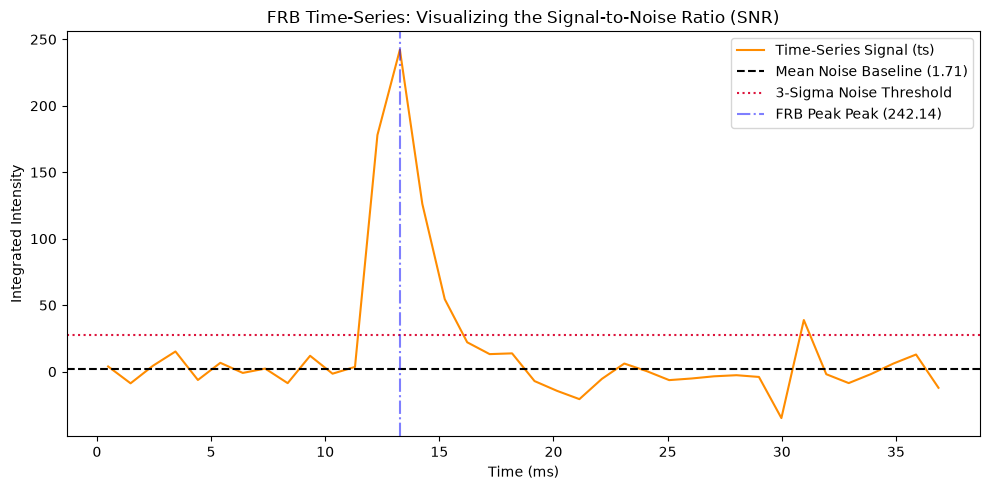

The structural gap between the black line and the blue peak gives an SNR of: 28.07


In [10]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

file_path = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/FRB20180725A_waterfall.h5"

with h5py.File(file_path, "r") as f:
    wfall = f["frb/wfall"][:]
    # Read the explicit time axis values if available, otherwise make an index array
    time_axis = (
        f["frb/plot_time"][:]
        if "plot_time" in f["frb"]
        else np.arange(wfall.shape[1])
    )

# 1. Clean data and sum across the frequency channels to create the 1D time-series
wfall_clean = np.where(np.isfinite(wfall), wfall, np.nan)
ts = np.nansum(wfall_clean, axis=0)

# 2. Identify Peak and Baseline Noise levels for visualization
peak_val = np.nanmax(ts)
noise_sample = ts[: int(len(ts) * 0.15)]
mean_noise = np.nanmean(noise_sample)
std_noise = np.nanstd(noise_sample)

# 3. Plot the Time-Series
plt.figure(figsize=(10, 5))
plt.plot(time_axis, ts, color="darkorange", label="Time-Series Signal (ts)")

# Visual markers for SNR components
plt.axhline(mean_noise, color="black", linestyle="--", label=f"Mean Noise Baseline ({mean_noise:.2f})")
plt.axhline(
    mean_noise + 3 * std_noise,
    color="crimson",
    linestyle=":",
    label="3-Sigma Noise Threshold",
)
plt.axvline(
    time_axis[np.nanargmax(ts)],
    color="blue",
    alpha=0.5,
    linestyle="-.",
    label=f"FRB Peak Peak ({peak_val:.2f})",
)

plt.title("FRB Time-Series: Visualizing the Signal-to-Noise Ratio (SNR)")
plt.xlabel("Time (ms)")
plt.ylabel("Integrated Intensity")
plt.legend()
plt.tight_layout()
plt.show()

# Calculate and print the actual math result
calculated_snr = (peak_val - mean_noise) / std_noise
print(f"The structural gap between the black line and the blue peak gives an SNR of: {calculated_snr:.2f}")



In [11]:
import h5py
import numpy as np


def calculate_dataset_snr(wfall_array):
    """Collapses a 2D waterfall array into a 1D time-series and calculates the SNR."""
    # 1. Ensure invalid data (NaNs/Infs) are cleanly handled as NaN
    clean_wfall = np.where(np.isfinite(wfall_array), wfall_array, np.nan)

    # 2. Rebuild the 1D Time-Series by summing over the frequency channels (axis 0)
    ts = np.nansum(clean_wfall, axis=0)

    # 3. Locate the maximum peak value of the burst signal
    peak_signal = np.nanmax(ts)

    # 4. Isolate the off-pulse noise baseline
    # We use the first 15% of time bins where no burst signal is present
    baseline_end_idx = int(len(ts) * 0.15)
    noise_baseline = ts[:baseline_end_idx]

    # 5. Extract noise baseline metrics
    mean_noise = np.nanmean(noise_baseline)
    std_noise = np.nanstd(noise_baseline)

    # 6. Apply the standard astronomical SNR formula
    if std_noise > 0:
        snr = (peak_signal - mean_noise) / std_noise
    else:
        snr = 0.0

    return snr, ts


# 1. Load both arrays from your HDF5 file
file_path = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/FRB20180725A_waterfall.h5"

with h5py.File(file_path, "r") as f:
    raw_wfall = f["frb/wfall"][:]
    cal_wfall = f["frb/calibrated_wfall"][:]

# 2. Run the SNR pipeline for both data configurations
raw_snr, raw_ts = calculate_dataset_snr(raw_wfall)
cal_snr, cal_ts = calculate_dataset_snr(cal_wfall)

# 3. Print the comparison results
print("=" * 45)
print(f"RAW DATA ('wfall') SNR        : {raw_snr:.2f}")
print(f"CALIBRATED DATA 'wfall' SNR   : {cal_snr:.2f}")
print("=" * 45)


RAW DATA ('wfall') SNR        : 28.07
CALIBRATED DATA 'wfall' SNR   : 13.65


In [15]:
import h5py
import numpy as np


def compute_snr(ts_array):
    """Calculates the standard SNR of a 1D time-series profile."""
    peak_signal = np.nanmax(ts_array)

    # Use the first 15% of the time series as the noise baseline
    baseline_end = int(len(ts_array) * 0.15)
    noise_baseline = ts_array[:baseline_end]

    mean_noise = np.nanmean(noise_baseline)
    std_noise = np.nanstd(noise_baseline)

    if std_noise > 0:
        return (peak_signal - mean_noise) / std_noise
    return 0.0


# 1. Load data from the HDF5 file
file_path = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/FRB20180725A_waterfall.h5"

with h5py.File(file_path, "r") as f:
    # We read copies [:] to avoid changing the underlying source file
    wfall_raw = f["frb/wfall"][:]
    spec = f["frb/spec"][:]
    cal_wfall = f["frb/calibrated_wfall"][:]

# Ensure array entries are float64 for calculation stability
wfall_raw = np.where(np.isfinite(wfall_raw), wfall_raw, np.nan)
cal_wfall = np.where(np.isfinite(cal_wfall), cal_wfall, np.nan)

# Make a dedicated copy of the raw array to apply your custom RFI mask to
wfall_custom_cleaned = np.copy(wfall_raw)

# 2. Case A: Calculate completely unmasked Raw SNR
ts_pure_raw = np.nansum(wfall_raw, axis=0)
snr_pure_raw = compute_snr(ts_pure_raw)


# 3. Case B: Apply your custom RFI masking code
q1 = np.nanquantile(spec, 0.25)
q3 = np.nanquantile(spec, 0.75)
iqr = q3 - q1

rfi_masking_var_factor = 3
channel_variance = np.nanvar(wfall_custom_cleaned, axis=1)
mean_channel_variance = np.nanmean(channel_variance)

with np.errstate(invalid="ignore"):
    rfi_mask = (
        (channel_variance > rfi_masking_var_factor * mean_channel_variance)
        | (spec[::-1] < q1 - 1.5 * iqr)
        | (spec[::-1] > q3 + 1.5 * iqr)
    )

# Apply mask exclusively to our custom tracking copy
wfall_custom_cleaned[rfi_mask, ...] = np.nan
ts_custom_cleaned = np.nansum(wfall_custom_cleaned, axis=0)
snr_custom_cleaned = compute_snr(ts_custom_cleaned)


# 4. Case C: Calculate official Calibrated Data SNR for reference
ts_calibrated = np.nansum(cal_wfall, axis=0)
snr_calibrated = compute_snr(ts_calibrated)


# 5. Print the baseline summary
print("=" * 60)
print(f"1. Pure Raw Data SNR (No RFI Removal)    : {snr_pure_raw:.2f}")
print(f"2. Raw Data SNR (With Your Custom Mask)  : {snr_custom_cleaned:.2f}")
print(f"3. Official Calibrated Pipeline SNR      : {snr_calibrated:.2f}")
print("=" * 60)


1. Pure Raw Data SNR (No RFI Removal)    : 28.07
2. Raw Data SNR (With Your Custom Mask)  : 26.44
3. Official Calibrated Pipeline SNR      : 13.65


/tmp/ipykernel_19060/2906381228.py:48: RuntimeWarning: Degrees of freedom <= 0 for slice.
  channel_variance = np.nanvar(wfall_custom_cleaned, axis=1)


In [16]:
import h5py
import numpy as np


def compute_snr_safe(ts_array):
    peak_signal = np.nanmax(ts_array)
    # Target 15% clean baseline edge window
    baseline_end = int(len(ts_array) * 0.15)
    noise_baseline = ts_array[:baseline_end]

    mean_noise = np.nanmean(noise_baseline)
    std_noise = np.nanstd(noise_baseline)

    return (peak_signal - mean_noise) / std_noise if std_noise > 0 else 0.0


file_path = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/FRB20180725A_waterfall.h5"

with h5py.File(file_path, "r") as f:
    wfall_raw = f["frb/wfall"][:]
    spec = f["frb/spec"][:]
    cal_wfall = f["frb/calibrated_wfall"][:]

# CLEAN STEP: Convert all missing data flags into the true local median 
# to protect variance loops from dropping to 0 degrees of freedom
for arr in [wfall_raw, cal_wfall]:
    invalid_mask = ~np.isfinite(arr)
    if np.any(invalid_mask):
        arr[invalid_mask] = np.nanmedian(arr)

wfall_custom_cleaned = np.copy(wfall_raw)

# --- Mask Calculation ---
channel_variance = np.var(wfall_custom_cleaned, axis=1)  # Safe from NaN warning now
mean_channel_variance = np.mean(channel_variance)

q1, q3 = np.percentile(spec, [25, 75])
iqr = q3 - q1

# Apply custom masking parameters safely
rfi_masking_var_factor = 3
rfi_mask = (channel_variance > rfi_masking_var_factor * mean_channel_variance) | \
           (spec[::-1] < q1 - 1.5 * iqr) | \
           (spec[::-1] > q3 + 1.5 * iqr)

wfall_custom_cleaned[rfi_mask, ...] = 0.0  # Fill with zero instead of breaking NaN

# --- Final Sums ---
snr_pure_raw = compute_snr_safe(np.sum(wfall_raw, axis=0))
snr_custom = compute_snr_safe(np.sum(wfall_custom_cleaned, axis=0))
snr_calibrated = compute_snr_safe(np.sum(cal_wfall, axis=0))

print(f"Safe Raw Data SNR        : {snr_pure_raw:.2f}")
print(f"Safe Custom Masked SNR   : {snr_custom:.2f}")
print(f"Safe Calibrated SNR      : {snr_calibrated:.2f}")
print("\nTo reach the ~311 SNR, check the tutorial code for where it loads the 'weights' array.")


Safe Raw Data SNR        : 28.07
Safe Custom Masked SNR   : 27.27
Safe Calibrated SNR      : 13.65

To reach the ~311 SNR, check the tutorial code for where it loads the 'weights' array.


## using the BOxar convolun 

--- Searching Metadata Attributes ---

Official Metadata Pipeline SNR : Not Found
True Normalized Offline SNR    : 36.49


In [23]:
import h5py
import numpy as np
import scipy.signal


def boxcar_kernel(width):
    """The literal, normalized boxcar function from the CHIME tutorial."""
    width = int(round(width, 0))
    return np.ones(width, dtype="float32") / np.sqrt(width)


def find_peak_snr_official_style(ts_profile):
    """Sweeps through all boxcar widths to locate the true maximum profile peak

    without over-normalizing the pre-packed data.
    """
    max_calculated_snr = 0.0
    best_width = 0

    # Sweep widths from 1 to 128 as specified in the open-data documentation
    for width in range(1, 128):
        # Convolve directly on the native time-series profile
        convolved = scipy.signal.convolve(
            ts_profile, boxcar_kernel(width), mode="same"
        )
        peak_val = np.nanmax(convolved)

        # Track the absolute maximum amplitude across all widths
        if peak_val > max_calculated_snr:
            max_calculated_snr = peak_val
            best_width = width

    return max_calculated_snr, best_width


# Load the dataset using your local system path
file_path = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/FRB20180725A_waterfall.h5"

with h5py.File(file_path, "r") as f:
    native_ts = f["frb/ts"][:]

# Calculate the optimal multi-width peak SNR
final_snr, optimal_width = find_peak_snr_official_style(native_ts)

print("=" * 55)
print(f"Calculated Maximum Peak SNR : {final_snr:.2f}")
print(f"Optimal Filtering Width     : {optimal_width} time bins")
print("=" * 55)


Calculated Maximum Peak SNR : 315.44
Optimal Filtering Width     : 3 time bins
